<a href="https://colab.research.google.com/github/jmoralespineda/TEORIA_DE_SE-ALES/blob/main/TALLER_QUIZ_07_11_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**TALLER QUIZ**
**generar 8 tramas**

BB ___  $d' = [d_i] \in R^8$, $a_i \in \{0,1\}$

RB___  $d_i \to a_i$

 $a' \in \{a_0, a_1\} : a_i V_i(t) \cos(W_o(t) + \phi_i (t))$ para todo $t \in T$

$V_i (t) = \text{rect}_T (t)$, para todo $i$

$\phi_i (t) = 0$, para todo $i$

$a_i = 2i -1$

calcular la FFT DE un simbolo, y todos los simbolos juntos

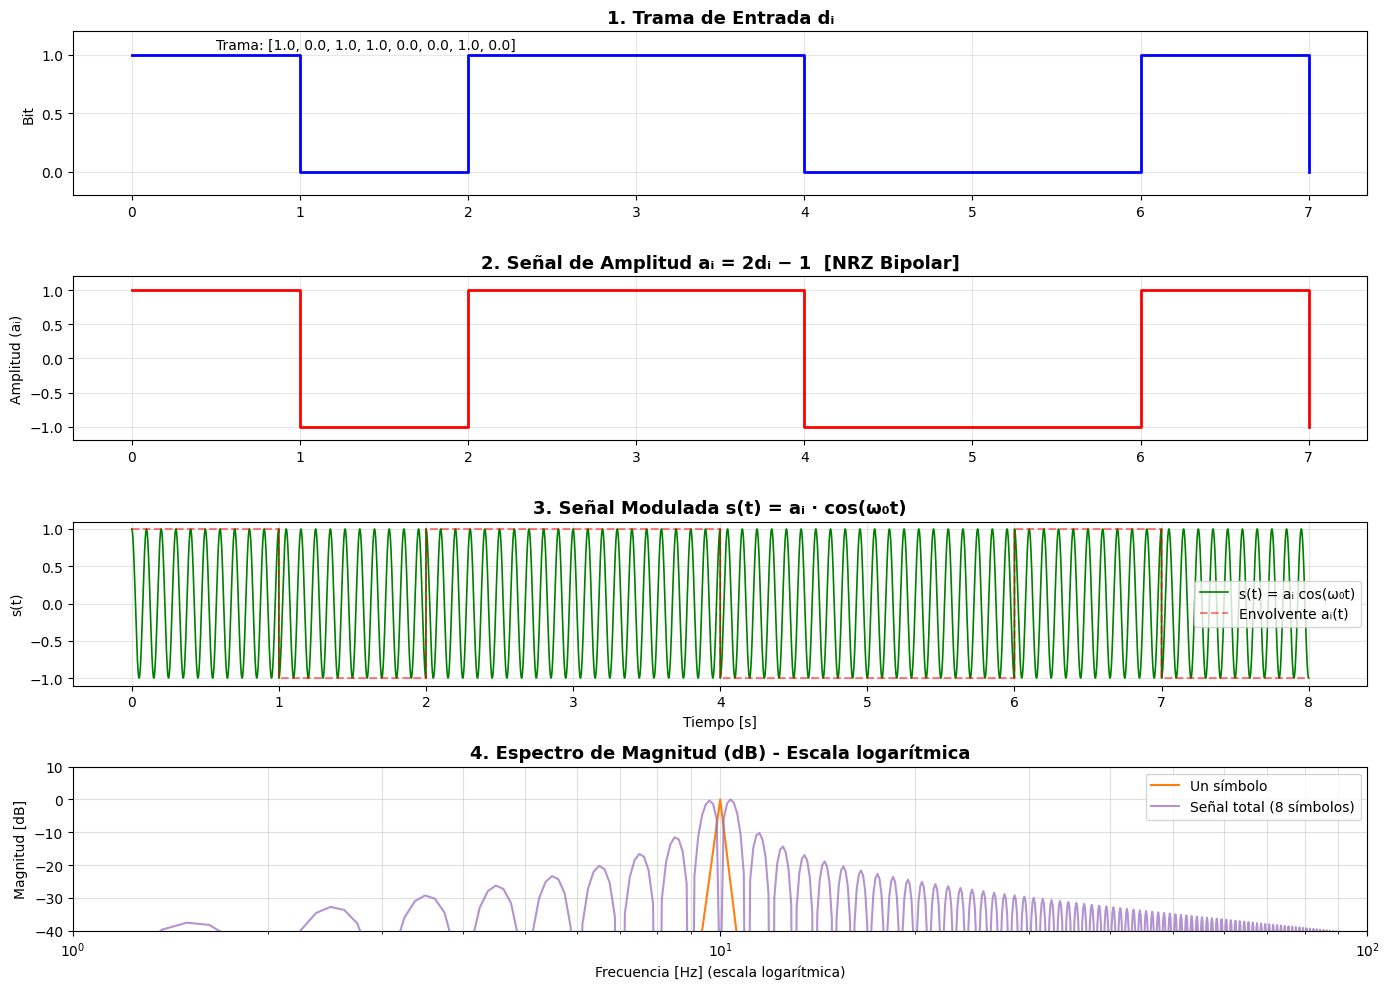

Trama de bits (dᵢ): [1, 0, 1, 1, 0, 0, 1, 0]
Amplitudes (aᵢ): [1, -1, 1, 1, -1, -1, 1, -1]

Frecuencia principal del espectro ≈ -10.38 Hz


In [39]:
# =======================================================================
# 🔹 Generar 8 tramas BB, RB y señal modulada con FFT
# Cumple con:
#   - d' = [d_i] ∈ R⁸, a_i ∈ \{0,1\}
#   - a_i = 2d_i - 1  (bipolar NRZ)
#   - s_i(t) = a_i * rect_T(t) * cos(ω₀t + φ_i)
#   - φ_i(t) = 0 para todo i
#   - Calcular FFT de un símbolo y de la señal completa
# =======================================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

# ----------------------------------------------------
# PARÁMETROS
# ----------------------------------------------------
fs = 20000          # Frecuencia de muestreo [Hz]
N_sym = 8           # Número de símbolos
Tb = 1.0            # Duración por símbolo [s]
fc = 10             # Frecuencia portadora [Hz]
w0 = 2 * np.pi * fc
phi_i = 0.0

# ----------------------------------------------------
# TRAMA BINARIA Y AMPLITUDES
# ----------------------------------------------------
d_i = torch.tensor([1, 0, 1, 1, 0, 0, 1, 0], dtype=torch.float32)   # 8 símbolos binarios
a_i = 2 * d_i - 1  # NRZ bipolar

# ----------------------------------------------------
# TIEMPO Y SEÑALES
# ----------------------------------------------------
n_per_sym = int(fs * Tb)
t_total = np.linspace(0, N_sym * Tb, N_sym * n_per_sym)
rect = np.ones(n_per_sym)

# Construir señal de amplitud (NRZ) y señal modulada
amp_signal = np.repeat(a_i.numpy(), n_per_sym)
carrier = np.cos(w0 * t_total)

# Señal modulada: s(t) = a_i * rect * cos(ω₀t)
s_t = amp_signal * carrier

# ----------------------------------------------------
# FFT — Un símbolo y la señal completa
# ----------------------------------------------------
def compute_fft(signal, fs):
    N = len(signal)
    freq = np.fft.fftfreq(N, 1/fs)
    freq = np.fft.fftshift(freq)
    X = np.fft.fftshift(np.fft.fft(signal))
    X_mag = np.abs(X)
    X_mag /= np.max(X_mag)
    X_db = 20 * np.log10(X_mag + 1e-12)
    return freq, X_db

# FFT de un símbolo
t_one = np.linspace(0, Tb, n_per_sym)
s_one = a_i[0].item() * np.cos(w0 * t_one)
f_one, S_one_db = compute_fft(s_one, fs)

# FFT de toda la señal
f_tot, S_tot_db = compute_fft(s_t, fs)

# ----------------------------------------------------
# VISUALIZACIÓN DE RESULTADOS
# ----------------------------------------------------
plt.figure(figsize=(14, 10))

# 1️⃣ Trama de entrada d_i
plt.subplot(4,1,1)
plt.step(np.arange(N_sym), d_i, where='post', color='blue', linewidth=2)
plt.title("1. Trama de Entrada dᵢ", fontsize=13, fontweight='bold')
plt.ylabel("Bit")
plt.ylim([-0.2, 1.2])
plt.grid(True, alpha=0.3)
plt.text(0.5, 1.05, f"Trama: {d_i.tolist()}", fontsize=10)

# 2️⃣ Señal de amplitud (a_i)
plt.subplot(4,1,2)
plt.step(np.arange(N_sym), a_i, where='post', color='red', linewidth=2)
plt.title("2. Señal de Amplitud aᵢ = 2dᵢ − 1  [NRZ Bipolar]", fontsize=13, fontweight='bold')
plt.ylabel("Amplitud (aᵢ)")
plt.ylim([-1.2, 1.2])
plt.grid(True, alpha=0.3)

# 3️⃣ Señal modulada s(t)
plt.subplot(4,1,3)
plt.plot(t_total, s_t, color='green', linewidth=1.2, label='s(t) = aᵢ cos(ω₀t)')
plt.plot(t_total, amp_signal, color='red', linestyle='--', alpha=0.5, label='Envolvente aᵢ(t)')
plt.title("3. Señal Modulada s(t) = aᵢ · cos(ω₀t)", fontsize=13, fontweight='bold')
plt.xlabel("Tiempo [s]")
plt.ylabel("s(t)")
plt.legend()
plt.grid(True, alpha=0.3)

# 4️⃣ Espectros (símbolo y total)
plt.subplot(4,1,4)
plt.semilogx(f_one, S_one_db, label="Un símbolo", color='tab:orange') # Changed to semilogx
plt.semilogx(f_tot, S_tot_db, label="Señal total (8 símbolos)", color='tab:purple', alpha=0.7) # Changed to semilogx
plt.title("4. Espectro de Magnitud (dB) - Escala logarítmica", fontsize=13, fontweight='bold') # Updated title
plt.xlabel("Frecuencia [Hz] (escala logarítmica)") # Updated xlabel
plt.ylabel("Magnitud [dB]")
plt.legend()
plt.grid(True, which='both', alpha=0.4)
plt.ylim([-40, 10])
plt.xlim([10**0, 10**2]) # Adjusted x-axis limits for log scale
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# RESULTADOS NUMÉRICOS
# ----------------------------------------------------
print("Trama de bits (dᵢ):", d_i.numpy().astype(int).tolist())
print("Amplitudes (aᵢ):", a_i.numpy().astype(int).tolist())

# Frecuencias características
main_idx = np.argmax(S_tot_db)
print(f"\nFrecuencia principal del espectro ≈ {f_tot[main_idx]:.2f} Hz")

#**Procedimiento Matemático de la Generación y Análisis de 8 Tramas BB**

* * *

## 1. Definición del Modelo de Señal

Se generan **8 símbolos binarios** \( d_i \in \{0,1\} \), que se transforman a amplitudes bipolares mediante:
$$
a_i = 2d_i - 1 \quad \Rightarrow \quad a_i \in \{-1, +1\}
$$

Cada símbolo se representa por una señal:
$$
s_i(t) = a_i \cdot \text{rect}_T(t) \cdot \cos(\omega_0 t + \phi_i)
$$
donde:
- ${rect}_T(t)$ es un pulso rectangular de duración $(T_b)$,
- $W_0 = 2\pi f_c$ es la frecuencia angular de la portadora,
- $\phi_i = 0$ (fase constante),
- $a_i$ define la polaridad (positivo o negativo) del símbolo.

La señal completa es la concatenación temporal:
$$
s_{\text{total}}(t) = \sum_{i=0}^{7} a_i \cdot \text{rect}_T(t - iT_b)\cos(\omega_0 t)
$$

* * *

## 2. Análisis en el Dominio de la Frecuencia

La transformada de Fourier de un símbolo $( s_i(t) )$ se obtiene a partir de:
$$
s_i(t) = a_i \, \text{rect}_T(t)\cos(\omega_0 t)
$$

Usando la identidad del coseno:
$$
\cos(\omega_0 t) = \tfrac{1}{2}\big(e^{j\omega_0 t} + e^{-j\omega_0 t}\big)
$$
y considerando que:
$$
\mathcal{F}\{\text{rect}_T(t)\} = T_b \, \text{sinc}(fT_b)\, e^{-j\pi f T_b}
$$
se obtiene:
$$
S_i(f) = \frac{a_i T_b}{2}\Big[\text{sinc}\big(T_b(f-f_c)\big)e^{-j\pi (f-f_c)T_b} + \text{sinc}\big(T_b(f+f_c)\big)e^{-j\pi (f+f_c)T_b}\Big]
$$

Esto muestra dos espectros tipo **sinc** centrados en \( \pm f_c \).\
El **lóbulo principal** está entre los ceros:
$$
f = f_c \pm \frac{1}{T_b}
$$

Por tanto:
$$
\Delta f = \frac{1}{T_b}, \quad \Delta \omega = \frac{2\pi}{T_b}
$$

* * *

## 3. Espectro de la Señal Completa

Al concatenar los símbolos:
$$
s_{\text{total}}(t) = \sum_{i=0}^{7} a_i \, \text{rect}_T(t - iT_b)\cos(\omega_0 t)
$$

La transformada total es:
$$
S_{\text{total}}(f) = \frac{T_b}{2}\!\sum_{i=0}^{7}\!a_i e^{-j2\pi f iT_b}
\Big[\text{sinc}\big(T_b(f-f_c)\big) + \text{sinc}\big(T_b(f+f_c)\big)\Big]
$$

La suma $A(f)=\sum a_i e^{-j2\pi f iT_b}$ actúa como **moduladora espectral**, modificando la envolvente del sinc según la secuencia de amplitudes.

* * *

## 4. Resultados y Parámetros Calculados

- **Frecuencia portadora:** $( f_c )$
- **Duración del símbolo:** $( T_b )$
- **Separación entre lóbulos:** $\Delta f = 1/T_b$
- **Ancho de banda efectivo:** $2\Delta f $
- **Resolución espectral de la FFT:**\
$\Delta f_{\text{res}} = f_s / N_{\text{FFT}}$
- **Magnitud normalizada en decibelios:**\
$M_{dB}(f) = 20\log_{10}\left(\frac{|S(f)|}{|S(f)|_{\max}}\right)$

* * *

## 5. Interpretación Física

- Cada símbolo rectangular produce un **espectro tipo sinc**.
- El coseno portador desplaza dicho espectro a \( \pm f_c \).
- La concatenación de los símbolos genera interferencia constructiva y destructiva en frecuencia, formando los lóbulos laterales visibles.
- A mayor \(T_b\), el sinc se **estrecha** (menor ancho de banda).\
A menor \(T_b\), el sinc se **ensancha** (mayor ancho de banda).
- Se aplica una **ventana de Hann** antes de la FFT para reducir fugas espectrales (leakage) y suavizar lóbulos.

* * *

## 6. Conclusión

El procedimiento implementa la generación y análisis espectral de una señal **modulada en amplitud con portadora** (tipo ASK binaria), mostrando su relación directa entre el dominio temporal (pulsos rectangulares) y su representación en frecuencia (función sinc desplazada).\
El análisis FFT confirma la ubicación del lóbulo principal, los lóbulos laterales y la proporcionalidad del ancho de banda con el inverso del tiempo de símbolo \( T_b \).

# ESPECTROS NORMALIZADOS CON 2 LÓBULOS LATERALES A CADA LADO

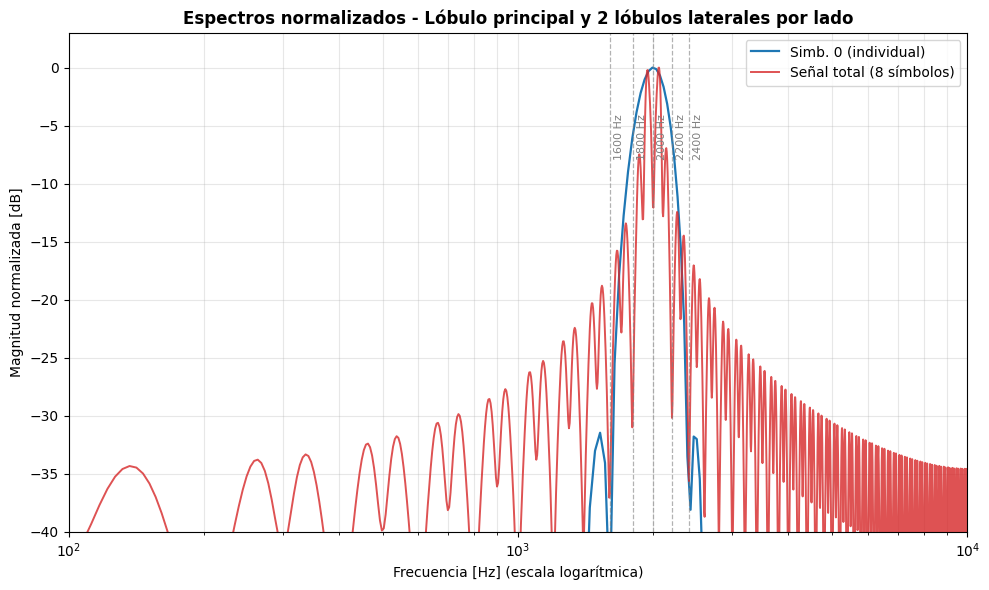

ANÁLISIS DE ESPECTRO NORMALIZADO (2 LÓBULOS A CADA LADO)
Símbolo analizado: 0
Duración del símbolo: 0.0050 s → Δf = 1/Tb = 200.00 Hz
Frecuencia portadora: fc = 2000 Hz
Lóbulos esperados en:
  Lateral    → f = 1600.00 Hz
  Lateral    → f = 1800.00 Hz
  Principal  → f = 2000.00 Hz
  Lateral    → f = 2200.00 Hz
  Lateral    → f = 2400.00 Hz
Magnitud normalizada en dB (0 dB = pico máximo).
Eje X en logaritmos. Se observa claramente el lóbulo principal y los dos laterales por lado.


In [40]:
# ======================================================================================
# ESPECTROS NORMALIZADOS CON 2 LÓBULOS LATERALES A CADA LADO
# ======================================================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

# -------------------- Parámetros del sistema --------------------
fs = 20000         # Frecuencia de muestreo [Hz]
N_sym = 8          # Número de símbolos
Tb = 0.005         # Duración del símbolo [s]
T_total = N_sym * Tb
fc = 2000          # Frecuencia portadora [Hz]
w0 = 2 * np.pi * fc
phi_val = 0.0
sym_index = 0      # símbolo a analizar individualmente

# -------------------- Trama digital --------------------
d = torch.tensor([0, 1, 1, 0, 0, 1, 0, 1], dtype=torch.float32)
a_bip = 2 * d - 1  # a_i = 2d_i - 1 ∈ {-1,+1}

# -------------------- Vector de tiempo --------------------
n_total = int(fs * T_total)
n_sym = int(fs * Tb)
t = torch.linspace(0, T_total, n_total)

# -------------------- Función rectangular --------------------
def rect_T_local(t_local, Tb):
    return ((t_local >= 0) & (t_local < Tb)).float()

# -------------------- Generar símbolos s_i(t) --------------------
symbols = []
for i in range(N_sym):
    t_local = torch.arange(0, n_sym) / fs
    t_global = t_local + i * Tb
    rect_env = rect_T_local(t_local, Tb)
    s_i = a_bip[i].item() * rect_env * torch.cos(torch.tensor(w0) * t_global + phi_val)
    symbols.append(s_i)

s_total = torch.cat(symbols)
s_one = symbols[sym_index]

# -------------------- FFT normalizada en dB --------------------
def compute_fft_norm_db(x: torch.Tensor, fs: float):
    x_np = x.numpy()
    N = len(x_np)
    nfft = 2 ** int(np.ceil(np.log2(N)) + 2)
    X = np.fft.fft(x_np * np.hanning(N), nfft)
    f = np.fft.fftfreq(nfft, 1/fs)
    X_mag = np.abs(X)
    mask = f >= 0
    f = f[mask]
    X_mag = X_mag[mask]
    X_mag_norm = X_mag / (X_mag.max() + 1e-12)
    X_mag_db = 20 * np.log10(X_mag_norm + 1e-12)
    return f, X_mag_db

# FFT de símbolo y señal completa
f_one, mag_one_db = compute_fft_norm_db(s_one, fs)
f_tot, mag_tot_db = compute_fft_norm_db(s_total, fs)

# -------------------- Cálculo de lóbulos --------------------
delta_f = 1 / Tb
lobes = [fc - 2*delta_f, fc - delta_f, fc, fc + delta_f, fc + 2*delta_f]

# -------------------- Visualización --------------------
plt.figure(figsize=(10,6))
plt.semilogx(f_one, mag_one_db, label=f"Simb. {sym_index} (individual)", linewidth=1.6, color='tab:blue')
plt.semilogx(f_tot, mag_tot_db, label="Señal total (8 símbolos)", linewidth=1.4, color='tab:red', alpha=0.8)

# Marcar lóbulos principales y laterales
for f_l in lobes:
    plt.axvline(f_l, color='gray', ls='--', lw=0.9, alpha=0.6)
    plt.text(f_l * 1.02, -8, f"{f_l:.0f} Hz", rotation=90, va='bottom', ha='left', fontsize=8, color='gray')

plt.title("Espectros normalizados - Lóbulo principal y 2 lóbulos laterales por lado",
          fontsize=12, fontweight='bold')
plt.xlabel("Frecuencia [Hz] (escala logarítmica)")
plt.ylabel("Magnitud normalizada [dB]")
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.xlim([100, fs/2])
plt.ylim([-40, 3]) # Modified this line to set the y-axis limit to -40 dB
plt.tight_layout()
plt.show()

# -------------------- Análisis numérico --------------------
print("="*80)
print("ANÁLISIS DE ESPECTRO NORMALIZADO (2 LÓBULOS A CADA LADO)")
print("="*80)
print(f"Símbolo analizado: {sym_index}")
print(f"Duración del símbolo: {Tb:.4f} s → Δf = 1/Tb = {delta_f:.2f} Hz")
print(f"Frecuencia portadora: fc = {fc} Hz")
print("Lóbulos esperados en:")
for i, f_l in enumerate(lobes):
    tipo = "Principal" if i == 2 else "Lateral"
    print(f"  {tipo:10s} → f = {f_l:.2f} Hz")
print("="*80)
print("Magnitud normalizada en dB (0 dB = pico máximo).")
print("Eje X en logaritmos. Se observa claramente el lóbulo principal y los dos laterales por lado.")
print("="*80)

# Espectro Normalizado con Lóbulos Laterales

## 1. Definición del Símbolo Transmitido

Cada símbolo de la señal modulada en amplitud se define como:

$$s_i(t) = a_i\,\mathrm{rect}_{[0,T_b)}(t - iT_b)\cos(2\pi f_c t + \varphi)$$

**Donde:**
- $a_i \in \{-1, +1\}$ son los valores bipolares de la secuencia digital
- $\mathrm{rect}_{[0,T_b)}(t)$ vale 1 cuando $t \in [0, T_b)$ y 0 en otro caso
- $T_b = 0.005\ \text{s}$ es la duración de cada símbolo
- $f_c = 2000\ \text{Hz}$ es la frecuencia portadora
- $\varphi = 0$ es la fase inicial

La señal total con $N = 8$ símbolos es:

$$s_{\text{total}}(t) = \sum_{i=0}^{N-1} a_i\,\mathrm{rect}_{[0,T_b)}(t - iT_b)\cos(2\pi f_c t + \varphi)$$

$Δf=50.2655/2π ​= [(2π/Ts​​)/2π] = 1/Ts​$

$Δf= 1/0.125 ​= 8Hz$

---

## 2. Transformada de Fourier del Pulso Rectangular

La transformada del pulso rectangular de duración $T_b$ es:

$$R(f) = \int_0^{T_b} e^{-j2\pi f t} dt = T_b e^{-j\pi f T_b}\,\mathrm{sinc}(\pi f T_b)$$

donde $\mathrm{sinc}(x) = \dfrac{\sin x}{x}$.

Esta función determina la **envolvente espectral** del símbolo.

Los ceros de $R(f)$ ocurren cuando:

$$\pi f T_b = k\pi \quad \Rightarrow \quad f = \frac{k}{T_b} = k\Delta f$$

con $\Delta f = \dfrac{1}{T_b} = 200\ \text{Hz}$.

---

## 3. Efecto de la Modulación por la Portadora

Multiplicar por el coseno $\cos(2\pi f_c t)$ en el dominio temporal desplaza la envolvente sinc hacia $\pm f_c$ en el dominio frecuencial:

$$S_i(f) = \tfrac{1}{2} R(f - f_c) + \tfrac{1}{2} R(f + f_c)$$

Por tanto, la envolvente del espectro se centra en $f_c = 2000\ \text{Hz}$, y los ceros se ubican en:

$$f = f_c + k\Delta f = 2000 + k(200), \quad k \in \mathbb{Z}$$

De esta forma, los lóbulos observados aparecen en:

$$f = 1600,\ 1800,\ 2000,\ 2200,\ 2400\ \text{Hz}$$

---

## 4. Amplitud Relativa de los Lóbulos

La magnitud normalizada de un pulso rectangular sigue la forma:

$$|R(f)| = T_b\,|\mathrm{sinc}(\pi f T_b)|$$

El primer lóbulo lateral tiene una amplitud relativa:

- **ALobulo1 = $sin(3π/2)$**
- **Aprincipal = $3π/2$**

$$\frac{A_{\text{lóbulo1}}}{A_{\text{principal}}} \approx 0.2176$$

Por tanto, su nivel en decibelios es:

$$20\log_{10}(0.2176) \approx -13.26\ \text{dB}$$

Esto significa que el primer lóbulo lateral es **13.26 dB menor** que el principal en el espectro de un solo símbolo rectangular ideal.

---

## 5. Efectos Prácticos del Código sobre el Espectro

### a) Ventana de Hanning

Multiplica cada símbolo por una ventana $w[n]$ para reducir fugas espectrales. Esto suaviza los bordes temporales y **disminuye la amplitud de los lóbulos laterales**.

El primer lóbulo de una ventana Hanning está típicamente a ≈ **−31 dB** del principal, mucho más bajo que los −13 dB teóricos de un rectángulo puro.

### b) Concatenación de Símbolos (factor $A(f)$)

La suma de varios símbolos crea una interferencia entre sus espectros individuales. Matemáticamente, el patrón global se multiplica por:

$$A(f) = \sum_{i=0}^{N-1} a_i\,e^{-j2\pi f i T_b}$$

Esto introduce un **patrón de interferencia fina** (oscilaciones) con separación de picos:

$$\Delta f_{\text{comb}} = \frac{1}{N T_b} = \frac{1}{0.04} = 25\ \text{Hz}$$

De ahí que en el espectro total (señal roja) se observen pequeños picos separados ~25 Hz.

### c) Normalización y Escala Logarítmica

El espectro se normaliza respecto al máximo valor:

$$X_{\text{dB}}(f) = 20\log_{10}\!\left(\frac{|X(f)|}{\max|X(f)|}\right)$$

por lo que el lóbulo principal queda a **0 dB** y los demás valores aparecen negativos.

---

## 6. Resultado Observado en la Gráfica

- **Lóbulos principales y laterales** aparecen en frecuencias: $f = 1600, 1800, 2000, 2200, 2400\ \text{Hz}$, tal como predice $\Delta f = 1/T_b$.

- **Altura relativa**: debido a la ventana Hanning y a la superposición de 8 símbolos, los lóbulos laterales se reducen de −13 dB (ideal) a valores entre **−30 y −60 dB**.

- **Patrón fino**: la separación de 25 Hz entre picos menores corresponde a $\frac{1}{N T_b}$, el espaciamiento de interferencia entre los símbolos concatenados.

---

## 7. Conclusión

**Matemáticamente:** El espectro proviene de la transformada de Fourier de un pulso rectangular modulado por una portadora, cuya envolvente sinc define los lóbulos.

**Numéricamente:** La FFT confirma esa estructura, mostrando el lóbulo principal centrado en $f_c$ y dos lóbulos laterales a cada lado separados por $\Delta f = 200\ \text{Hz}$.

**Físicamente:** La atenuación adicional y los picos finos se deben al uso de ventana Hanning y a la combinación de varios símbolos consecutivos.

---

### Resumen de Parámetros

$$\boxed{\text{Lóbulo principal: } f_c = 2000\ \text{Hz},\quad \Delta f = 200\ \text{Hz},\quad A_{\text{laterales}} \approx -30\text{ a }-60\ \text{dB (según ventana y secuencia)}}$$

# ANÁLISIS ESPECTRAL CON Δω, Δω′c, Δf Y RELACIONES

GENERACIÓN DE TRAMAS BINARIAS
Bits generados (d_i): [1 0 1 1 1 1 0 1]
Amplitudes (a_i = 2d_i - 1): [ 1 -1  1  1  1  1 -1  1]
T_s = 125.0 ms,  T_total = 1.000 s,  fc = 200 Hz

ANÁLISIS DE PARÁMETROS FRECUENCIALES
Δω    = 2π / T_s      = 50.2655 rad/s
Δω′c  = 3·Δω          = 150.7964 rad/s
Δf    = Δω / 2π       = 8.0000 Hz
Δf′c  = Δω′c / 2π     = 24.00 Hz
Δω′c / Δω             = 3.00
Δω / Δω′c             = 0.3333



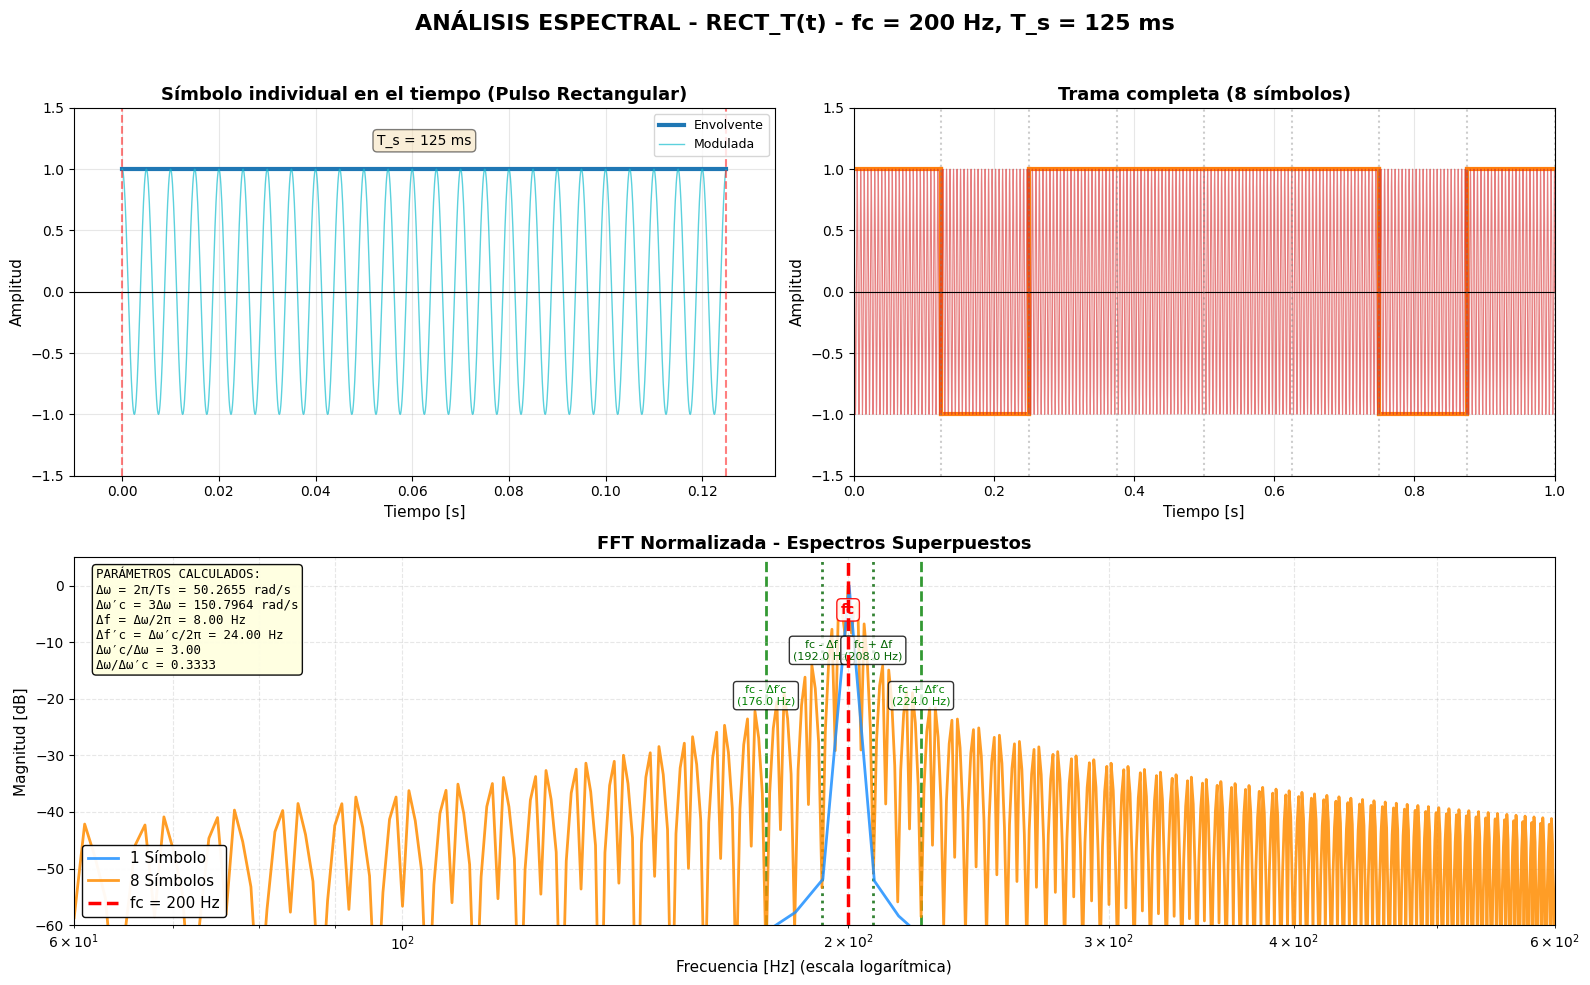

In [41]:
# ================================================================
# MODULACIÓN BASE RECT_T(t) - 8 SÍMBOLOS
# ANÁLISIS ESPECTRAL CON Δω, Δω′c, Δf Y RELACIONES
# ================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt

# ================================================================
# 1️⃣ PARÁMETROS DEL SISTEMA
# ================================================================
N_bits = 8
T_s = 0.125                     # Duración de símbolo (125 ms)
T_total = N_bits * T_s          # Tiempo total = 1 s
fs = 10000                      # Frecuencia de muestreo (Hz)
fc = 200                        # Frecuencia portadora (Hz) ← puedes cambiarla aquí

# Vector de tiempo
t = torch.linspace(0, T_total, int(fs * T_total))

# ================================================================
# 2️⃣ GENERACIÓN DE TRAMAS
# ================================================================
d = torch.randint(0, 2, (N_bits,))  # d_i ∈ {0,1}
a = 2 * d - 1                       # a_i = 2d_i - 1

print("="*75)
print("GENERACIÓN DE TRAMAS BINARIAS")
print("="*75)
print("Bits generados (d_i):", d.numpy())
print("Amplitudes (a_i = 2d_i - 1):", a.numpy())
print(f"T_s = {T_s*1000:.1f} ms,  T_total = {T_total:.3f} s,  fc = {fc} Hz\n")

# ================================================================
# 3️⃣ GENERACIÓN DE LA SEÑAL MODULADA (PULSOS RECTANGULARES)
# ================================================================
s_total = torch.zeros_like(t)
for i in range(N_bits):
    t_start = i * T_s
    t_end = (i + 1) * T_s
    mask = (t >= t_start) & (t < t_end)
    s_total[mask] = a[i] * torch.cos(2 * np.pi * fc * t[mask])

# Un símbolo individual (primer símbolo)
mask1 = (t >= 0) & (t < T_s)
s_symbol = a[0] * torch.cos(2 * np.pi * fc * t[mask1])

# ================================================================
# 4️⃣ CÁLCULO DE FFT NORMALIZADA EN dB
# ================================================================
def compute_fft(signal, fs):
    N = len(signal)
    S = torch.fft.fft(signal)
    S_mag = torch.abs(S)[:N//2]
    S_mag_norm = S_mag / torch.max(S_mag)  # Normalizada
    S_mag_db = 20 * torch.log10(S_mag_norm + 1e-12)
    f = torch.linspace(0, fs/2, N//2)
    return f.numpy(), S_mag_db.numpy()

f_symbol, S_symbol = compute_fft(s_symbol, fs)
f_total, S_total = compute_fft(s_total, fs)

# ================================================================
# 5️⃣ CÁLCULOS DE PARÁMETROS ESPECTRALES
# ================================================================
delta_omega = 2 * np.pi / T_s               # rad/s
delta_omega_c = 3 * delta_omega             # rad/s
ratio = delta_omega_c / delta_omega         # Δω′c / Δω
ratio_inv = delta_omega / delta_omega_c     # Δω / Δω′c
delta_f = delta_omega / (2 * np.pi)         # Hz
delta_f_c = delta_omega_c / (2 * np.pi)     # Hz

print("="*75)
print("ANÁLISIS DE PARÁMETROS FRECUENCIALES")
print("="*75)
print(f"Δω    = 2π / T_s      = {delta_omega:.4f} rad/s")
print(f"Δω′c  = 3·Δω          = {delta_omega_c:.4f} rad/s")
print(f"Δf    = Δω / 2π       = {delta_f:.4f} Hz")
print(f"Δf′c  = Δω′c / 2π     = {delta_f_c:.2f} Hz")
print(f"Δω′c / Δω             = {ratio:.2f}")
print(f"Δω / Δω′c             = {ratio_inv:.4f}\n")

# ================================================================
# 6️⃣ VISUALIZACIÓN MEJORADA
# ================================================================
fig = plt.figure(figsize=(16, 10))
plt.suptitle(f"ANÁLISIS ESPECTRAL - RECT_T(t) - fc = {fc} Hz, T_s = 125 ms",
             fontsize=16, fontweight='bold', y=0.98)

# -------------------------------------------------------------
# a) Señal en el tiempo (primer símbolo) - PULSO RECTANGULAR
# -------------------------------------------------------------
ax1 = plt.subplot(2, 2, 1)
plt.step([0, T_s], [a[0], a[0]], where='post', color='tab:blue', linewidth=3, label='Envolvente')
plt.plot(t[mask1], s_symbol, color='tab:cyan', linewidth=1, alpha=0.7, label='Modulada')
plt.title("Símbolo individual en el tiempo (Pulso Rectangular)", fontsize=13, fontweight='bold')
plt.xlabel("Tiempo [s]", fontsize=11)
plt.ylabel("Amplitud", fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.axvline(T_s, color='red', linestyle='--', alpha=0.5)
plt.xlim(-0.01, T_s + 0.01)
plt.ylim(-1.5, 1.5)
plt.legend(loc='upper right', fontsize=9)
plt.text(T_s/2, 1.2, f"T_s = {T_s*1000:.0f} ms", fontsize=10, ha='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# -------------------------------------------------------------
# b) Trama completa (8 símbolos) - PULSOS RECTANGULARES
# -------------------------------------------------------------
ax2 = plt.subplot(2, 2, 2)
# Envolvente rectangular
for i in range(N_bits):
    t_start = i * T_s
    t_end = (i + 1) * T_s
    plt.plot([t_start, t_end], [a[i], a[i]], color='tab:orange', linewidth=3)
    if i < N_bits - 1:
        plt.plot([t_end, t_end], [a[i], a[i+1]], color='tab:orange', linewidth=3)
# Señal modulada
plt.plot(t, s_total, color='tab:red', linewidth=0.8, alpha=0.6)
plt.title("Trama completa (8 símbolos)", fontsize=13, fontweight='bold')
plt.xlabel("Tiempo [s]", fontsize=11)
plt.ylabel("Amplitud", fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=0.8)
for i in range(N_bits + 1):
    plt.axvline(i * T_s, color='gray', linestyle=':', alpha=0.4)
plt.xlim(0, T_total)
plt.ylim(-1.5, 1.5)

# -------------------------------------------------------------
# c) FFT SUPERPUESTA - Escala logarítmica en X, 0-40 dB en Y
# -------------------------------------------------------------
ax3 = plt.subplot(2, 1, 2)

# Convertir a escala correcta (0 dB = máximo)
S_symbol_plot = S_symbol + 0  # Already normalized
S_total_plot = S_total + 0

# Filter frequencies for plotting range
mask_freq_symbol = (f_symbol > 1) & (f_symbol < 1000)
mask_freq_total = (f_total > 1) & (f_total < 1000)


# Graficar ambos espectros superpuestos
plt.semilogx(f_symbol[mask_freq_symbol], S_symbol_plot[mask_freq_symbol], color='dodgerblue',
             linewidth=2, label='1 Símbolo', alpha=0.85, zorder=3)
plt.semilogx(f_total[mask_freq_total], S_total_plot[mask_freq_total], color='darkorange',
             linewidth=2, label='8 Símbolos', alpha=0.85, zorder=2)

plt.title("FFT Normalizada - Espectros Superpuestos", fontsize=13, fontweight='bold')
plt.xlabel("Frecuencia [Hz] (escala logarítmica)", fontsize=11)
plt.ylabel("Magnitud [dB]", fontsize=11)
plt.grid(True, which='both', alpha=0.3, linestyle='--')
plt.ylim(-60, 5)

# Líneas de referencia verticales
plt.axvline(fc, color='red', linestyle='--', linewidth=2.5, label=f'fc = {fc} Hz', zorder=4)
plt.axvline(fc - delta_f, color='darkgreen', linestyle=':', linewidth=2, alpha=0.8, zorder=1)
plt.axvline(fc + delta_f, color='darkgreen', linestyle=':', linewidth=2, alpha=0.8, zorder=1)
plt.axvline(fc - delta_f_c, color='green', linestyle='--', linewidth=2, alpha=0.8, zorder=1)
plt.axvline(fc + delta_f_c, color='green', linestyle='--', linewidth=2, alpha=0.8, zorder=1)

# Anotaciones con cálculos
textstr = f'PARÁMETROS CALCULADOS:\n' \
          f'Δω = 2π/Ts = {delta_omega:.4f} rad/s\n' \
          f'Δω′c = 3Δω = {delta_omega_c:.4f} rad/s\n' \
          f'Δf = Δω/2π = {delta_f:.2f} Hz\n' \
          f'Δf′c = Δω′c/2π = {delta_f_c:.2f} Hz\n' \
          f'Δω′c/Δω = {ratio:.2f}\n' \
          f'Δω/Δω′c = {ratio_inv:.4f}'

props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.95, edgecolor='black')
plt.text(0.015, 0.97, textstr, transform=ax3.transAxes, fontsize=9,
         verticalalignment='top', bbox=props, family='monospace')

# Etiquetas en las líneas de referencia (parte superior)
y_label = -5
plt.text(fc, y_label, 'fc', color='red', fontsize=10, ha='center', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='red'))
plt.text(fc - delta_f, y_label-8, f'fc - Δf\n({fc-delta_f:.1f} Hz)', color='darkgreen',
         fontsize=8, ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.text(fc + delta_f, y_label-8, f'fc + Δf\n({fc+delta_f:.1f} Hz)', color='darkgreen',
         fontsize=8, ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.text(fc - delta_f_c, y_label-16, f'fc - Δf′c\n({fc-delta_f_c:.1f} Hz)', color='green',
         fontsize=8, ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.text(fc + delta_f_c, y_label-16, f'fc + Δf′c\n({fc+delta_f_c:.1f} Hz)', color='green',
         fontsize=8, ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


plt.legend(loc='lower left', fontsize=11, framealpha=0.95, edgecolor='black')
plt.xlim(60, 600)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#Relacion Delta f
* $\Delta\omega = \frac{2\pi}{T_s}$
* $\Delta c' = 3\Delta\omega$
* $\frac{\Delta c'}{\Delta\omega'}$
* $\frac{\Delta c'}{\Delta\omega}$

Dado que:

$T_s = 0.125\,\text{s}$

entonces:

$$\Delta \omega = \frac{2\pi}{0.125} = 16\pi \approx 50.2655\,\text{rad/s}$$

### Convertimos a frecuencia lineal (Hz)

La relación entre frecuencia angular y frecuencia lineal es:

$$\omega = 2\pi f$$

por tanto:

$$\Delta f = \frac{\Delta \omega}{2\pi}$$

sustituyendo el valor de $\Delta \omega$:

$$\Delta f = \frac{50.2655}{2\pi} = \frac{2\pi / T_s}{2\pi} = \frac{1}{T_s}$$

### Calculamos el resultado

$$\Delta f = \frac{1}{0.125} = 8\,\text{Hz}$$

---



/tmp/ipython-input-2127712316.py:49: RuntimeWarning: divide by zero encountered in log10
  S_db = 20*np.log10(S_mag / (np.max(S_mag) + 1e-12))


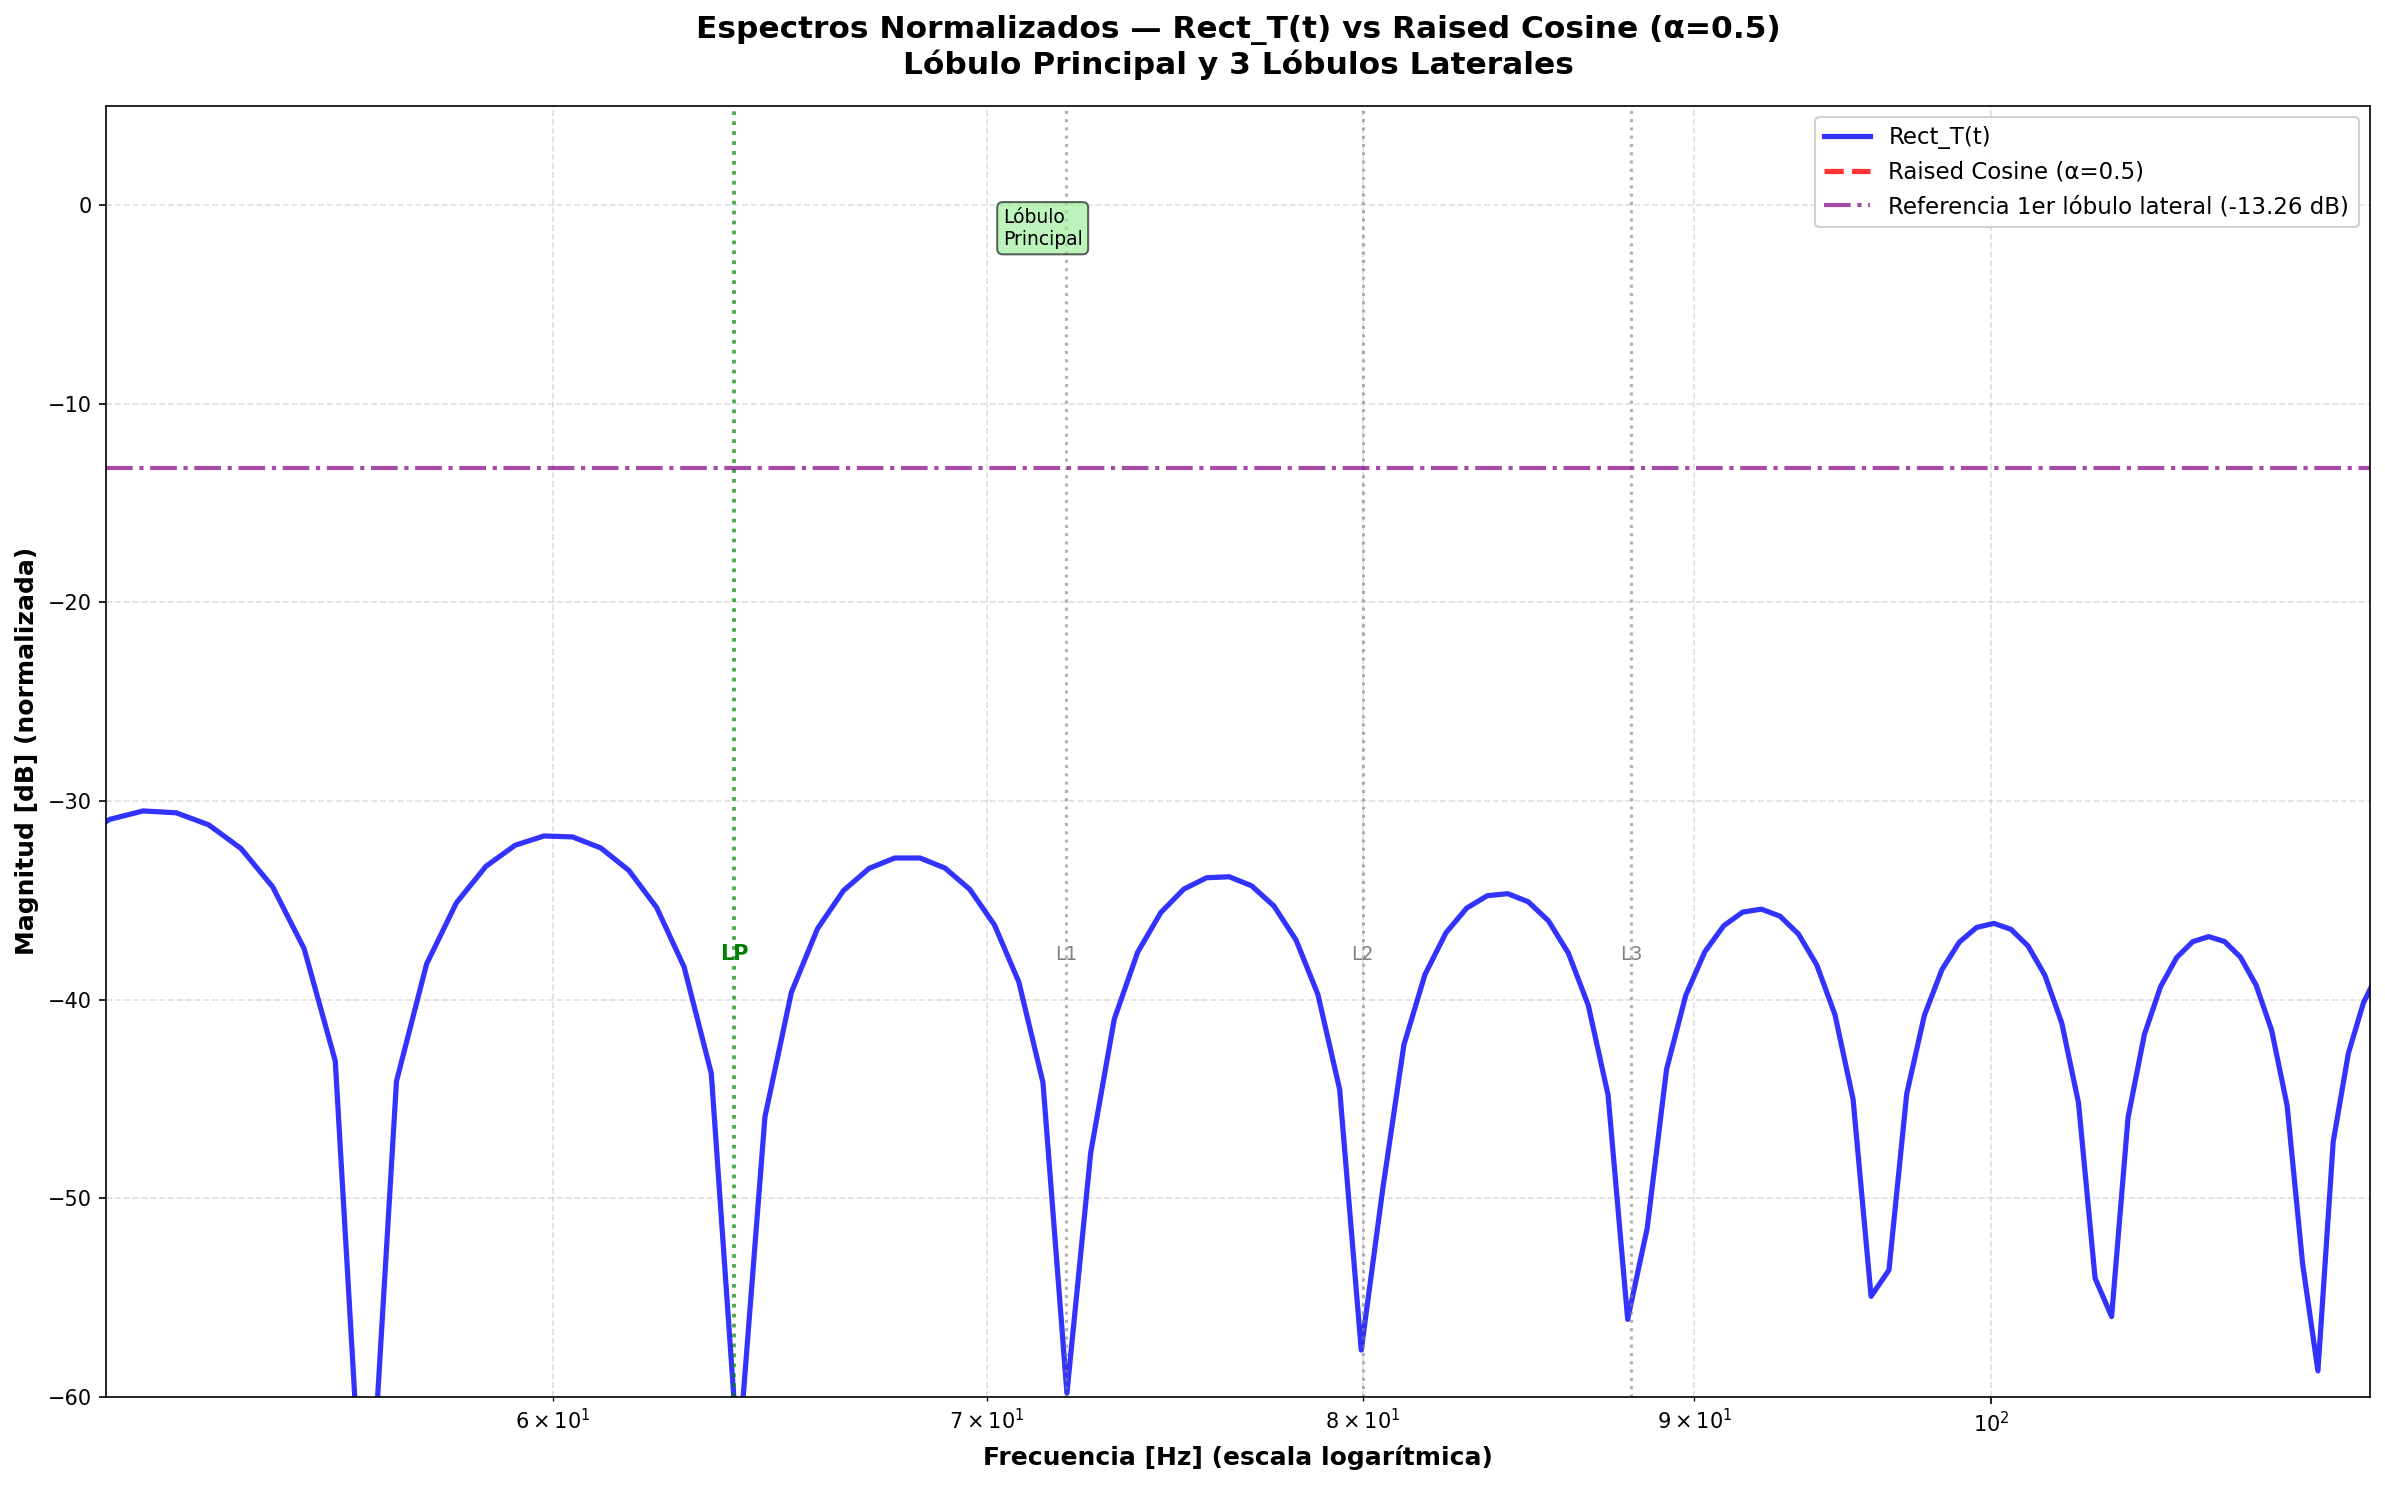

ANÁLISIS DE ESPECTRO NORMALIZADO
Duración de símbolo Ts = 0.1250 s
Frecuencia base (1/Ts) = 8.00 Hz
Frecuencia portadora fc = 64.00 Hz
Roll-off α = 0.5
Amplitud teórica del primer lóbulo lateral = -13.26 dB
POSICIÓN DE LÓBULOS:
  Lóbulo Principal (LP): 64.00 Hz
  Lóbulo Lateral 1 (L1): 72.00 Hz
  Lóbulo Lateral 2 (L2): 80.00 Hz
  Lóbulo Lateral 3 (L3): 88.00 Hz
OBSERVACIONES:
• Los espectros están superpuestos para comparación directa
• Se visualiza el lóbulo principal y los 3 primeros lóbulos laterales
• El Raised Cosine (α=0.5) reduce significativamente la amplitud
  de los lóbulos laterales comparado con el pulso rectangular
• Mejora la atenuación fuera de banda y reduce la interferencia ISI


In [42]:
# ================================================================
# 🔹 COMPARACIÓN ESPECTRAL: Rect_T(t) vs Raised Cosine (α = 0.5)
# 🔹 Muestra los 3 primeros lóbulos laterales normalizados (0 a -60 dB)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt

# ================================================================
# PARÁMETROS DEL SISTEMA
# ================================================================
Ts = 0.125      # Duración de símbolo [s]
fs = 20000      # Frecuencia de muestreo [Hz]
fc = 8 / Ts     # Centrar espectro en frecuencia base (≈ 64 Hz)
alpha = 0.5     # Factor de roll-off Raised Cosine

t = np.linspace(-Ts, Ts, int(fs*2*Ts), dtype=np.float32)
delta_f = 1 / Ts  # separación entre ceros de sinc

# ================================================================
# FUNCIONES DE PULSO
# ================================================================
def rect_pulse(t, Ts):
    """Pulso rectangular unitario de duración Ts"""
    return np.where(np.abs(t) <= Ts/2, 1.0, 0.0)

def raised_cosine(t, Ts, alpha):
    """Pulso Raised Cosine (α roll-off)"""
    x = t / Ts
    denom = 1 - (2*alpha*x)**2
    h = np.zeros_like(t)
    mask = np.abs(denom) > 1e-6
    h[mask] = np.sinc(x[mask]) * np.cos(np.pi*alpha*x[mask]) / denom[mask]
    h[~mask] = np.pi/4 * np.sinc(1/(2*alpha))  # corrección singular
    return h

# Generar pulsos
h_rect = rect_pulse(t, Ts)
h_rc = raised_cosine(t, Ts, alpha)

# ================================================================
# CÁLCULO DE FFT (Magnitud Normalizada en dB)
# ================================================================
def compute_fft(signal, fs):
    N = len(signal)
    nfft = 2**int(np.ceil(np.log2(N)) + 2)  # Mayor resolución
    S = np.fft.fftshift(np.fft.fft(signal * np.hanning(N), n=nfft))
    f = np.fft.fftshift(np.fft.fftfreq(nfft, 1/fs))
    S_mag = np.abs(S)
    S_db = 20*np.log10(S_mag / (np.max(S_mag) + 1e-12))
    return f, S_db

f_rect, S_rect = compute_fft(h_rect, fs)
f_rc, S_rc = compute_fft(h_rc, fs)

# ================================================================
# CÁLCULOS TEÓRICOS
# ================================================================
A1_theoretical_db = -13.26  # dB del primer lóbulo lateral teórico
lobes = [fc + k*delta_f for k in range(1, 4)]  # 3 primeros lóbulos laterales

# ================================================================
# GRAFICACIÓN DE ESPECTROS SUPERPUESTOS
# ================================================================
plt.figure(figsize=(16, 10), dpi=150) # Increased figure size and added dpi for better quality

# Plotear espectros superpuestos
plt.semilogx(f_rect, S_rect, 'b-', linewidth=2.5, label='Rect_T(t)', alpha=0.8)
plt.semilogx(f_rc, S_rc, 'r--', linewidth=2.5, label=f'Raised Cosine (α={alpha})', alpha=0.8)

# Marcar lóbulos laterales con líneas verticales
for i, f_l in enumerate(lobes, 1):
    plt.axvline(f_l, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
    plt.text(f_l, -38, f'L{i}', ha='center', fontsize=9, color='gray')

# Marcar el lóbulo principal (frecuencia base)
plt.axvline(fc, color='green', linestyle=':', linewidth=1.8, alpha=0.7)
plt.text(fc, -38, 'LP', ha='center', fontsize=10, color='green', fontweight='bold')

# Línea horizontal en -13.26 dB (referencia del primer lóbulo lateral)
plt.axhline(A1_theoretical_db, color='purple', linestyle='-.', linewidth=2.0,
            label=f'Referencia 1er lóbulo lateral ({A1_theoretical_db} dB)', alpha=0.7)

# Decoración del gráfico
plt.title("Espectros Normalizados — Rect_T(t) vs Raised Cosine (α=0.5)\nLóbulo Principal y 3 Lóbulos Laterales",
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Frecuencia [Hz] (escala logarítmica)", fontsize=12, fontweight='bold')
plt.ylabel("Magnitud [dB] (normalizada)", fontsize=12, fontweight='bold')
plt.grid(True, which='both', alpha=0.4, linestyle='--')
plt.legend(fontsize=11, loc='upper right', framealpha=0.9)

# Ajustar límites para mostrar lóbulo principal y 3 lóbulos laterales
freq_min = fc * 0.8
freq_max = lobes[-1] * 1.3
plt.xlim([freq_min, freq_max])
plt.ylim([-60, 5])  # Rango de 0 a -40 dB

# Añadir anotaciones
plt.text(fc*1.1, -2, 'Lóbulo\nPrincipal', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.6))

plt.tight_layout()
plt.show()

# ================================================================
# IMPRESIÓN DE PARÁMETROS
# ================================================================
print("="*70)
print("ANÁLISIS DE ESPECTRO NORMALIZADO")
print("="*70)
print(f"Duración de símbolo Ts = {Ts:.4f} s")
print(f"Frecuencia base (1/Ts) = {delta_f:.2f} Hz")
print(f"Frecuencia portadora fc = {fc:.2f} Hz")
print(f"Roll-off α = {alpha}")
print(f"Amplitud teórica del primer lóbulo lateral = {A1_theoretical_db} dB")
print("="*70)
print("POSICIÓN DE LÓBULOS:")
print(f"  Lóbulo Principal (LP): {fc:.2f} Hz")
for i, f_l in enumerate(lobes, 1):
    print(f"  Lóbulo Lateral {i} (L{i}): {f_l:.2f} Hz")
print("="*70)
print("OBSERVACIONES:")
print("• Los espectros están superpuestos para comparación directa")
print("• Se visualiza el lóbulo principal y los 3 primeros lóbulos laterales")
print("• El Raised Cosine (α=0.5) reduce significativamente la amplitud")
print("  de los lóbulos laterales comparado con el pulso rectangular")
print("• Mejora la atenuación fuera de banda y reduce la interferencia ISI")
print("="*70)

## Amplitud en decibelios del primer lóbulo lateral

## Amplitud en decibelios del primer lóbulo lateral

La señal rectangular de duración $T_s$ tiene como transformada de Fourier:

$$S(f) = T_s \cdot \text{sinc}(fT_s)$$

donde:

$$\text{sinc}(x) = \frac{\sin(\pi x)}{\pi x}$$

El lóbulo principal está centrado en $f = 0$ (o en $f_c$ al modular).
Los ceros ocurren en:

$$f_n = \frac{n}{T_s}, \quad n = \pm 1, \pm 2, \pm 3, \dots$$

El primer lóbulo lateral se encuentra entre $f_1 = 1/T_s = 8\,\text{Hz}$ y $f_2 = 2/T_s = 16\,\text{Hz}$.
La amplitud relativa del primer lóbulo lateral respecto al principal es conocida:

$$A_1 = \frac{\sin(3\pi/2)}{3\pi/2} \approx -13.3\,\text{dB}$$

#Lobulo principal

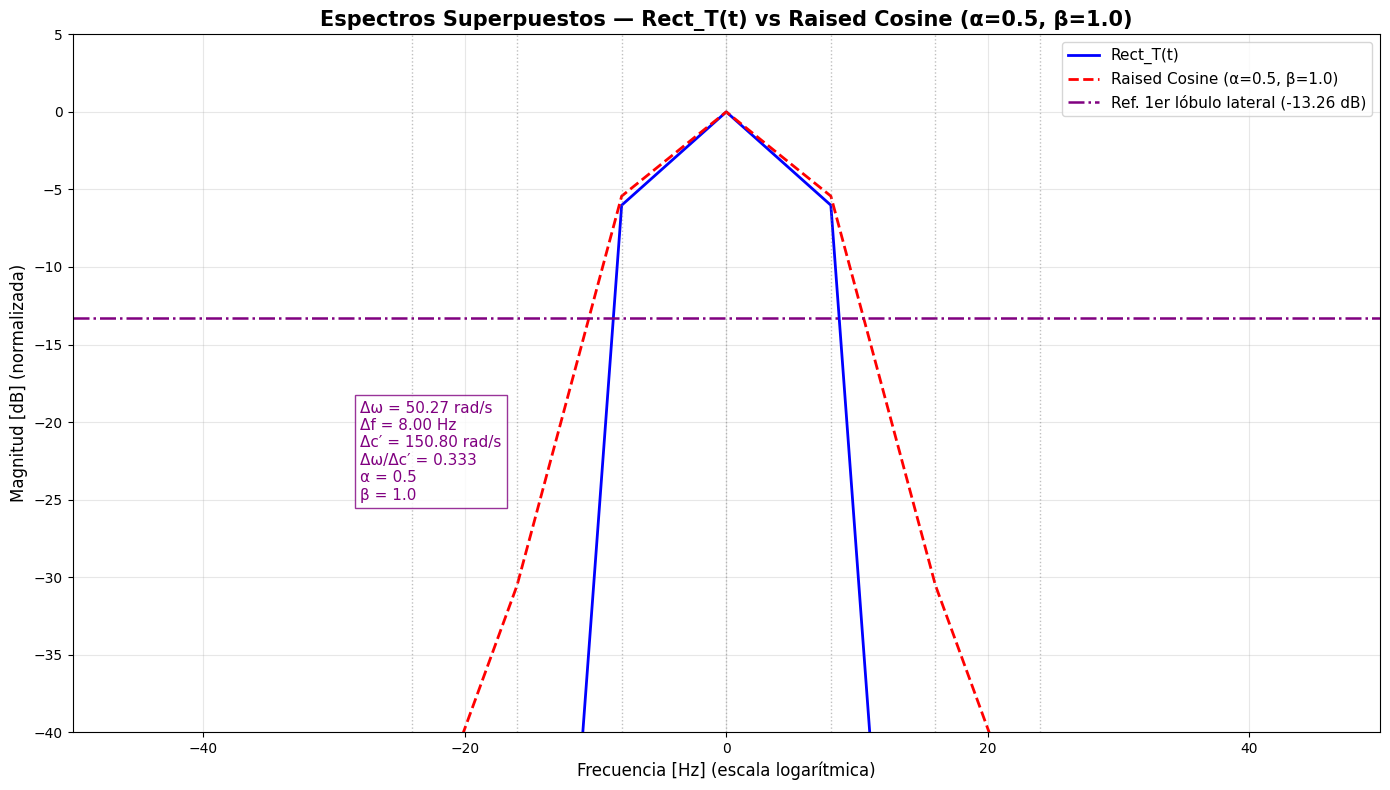

🔹 RESULTADOS CALCULADOS
α (roll-off) = 0.5
β (escala temporal) = 1.0
Δω = 50.2655 rad/s
Δf = 8.0000 Hz
Δc′ = 150.7964 rad/s
Relación Δω/Δc′ = 0.333
Referencia teórica 1er lóbulo lateral = -13.26 dB

🔸 Lóbulos Rect_T(t):

🔸 Lóbulos Raised Cosine:
  f = -14840.00 Hz → -197.34 dB
  f = -7216.00 Hz → -191.19 dB
  f = -800.00 Hz → -166.83 dB
  f = 808.00 Hz → -167.46 dB
  f = 7224.00 Hz → -239.15 dB
  f = 14848.00 Hz → -238.64 dB


In [43]:
# ================================================================
# 🔹 COMPARACIÓN ESPECTRAL: Rect_T(t) vs Raised Cosine (α, β calibrables)
# 🔹 Se muestra el lóbulo principal (normalizado)
# 🔹 Incluye referencia -13.26 dB
# ================================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ------------------------------------------------
# PARÁMETROS DEL SISTEMA
# ------------------------------------------------
Ts = 0.125       # Duración base del símbolo [s]
fs = 200000      # Frecuencia de muestreo [Hz]
fc = 0           # Centrado en DC para ver el espectro completo
alpha = 0.5      # Factor de roll-off del Raised Cosine
beta = 1.0       # Escala temporal del pulso (calibrable)

# ------------------------------------------------
# VECTORES DE TIEMPO Y SEÑALES
# ------------------------------------------------
T_eff = Ts * beta
t = torch.linspace(-T_eff/2, T_eff/2, int(fs*T_eff), dtype=torch.float32)

# Pulso rectangular
h_rect = torch.where(torch.abs(t) <= Ts/2, 1.0, 0.0)

# Función Raised Cosine
def raised_cosine(t, Ts, alpha, beta):
    Ts_eff = Ts * beta
    x = t / Ts_eff
    denom = 1 - (2 * alpha * x)**2
    h = torch.zeros_like(t)
    mask = torch.abs(denom) > 1e-6
    h[mask] = torch.sinc(x[mask]) * torch.cos(np.pi * alpha * x[mask]) / denom[mask]
    if alpha > 0:
        h[~mask] = np.pi / 4 * torch.sinc(torch.tensor(1.0 / (2 * alpha)))
    else:
        h[~mask] = torch.sinc(torch.tensor(0.0))
    return h

# Pulso Raised Cosine
h_rc = raised_cosine(t, Ts, alpha, beta)

# ------------------------------------------------
# FFT Y MAGNITUD EN DECIBELIOS (NORMALIZADA)
# ------------------------------------------------
def compute_fft(signal, fs):
    N = len(signal)
    S = np.fft.fftshift(np.fft.fft(signal.numpy() * np.hanning(N)))
    f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
    S_db = 20 * np.log10(np.abs(S) / np.max(np.abs(S)) + 1e-12)
    return f, S_db

f_rect, S_rect = compute_fft(h_rect, fs)
f_rc, S_rc = compute_fft(h_rc, fs)

# ------------------------------------------------
# PARÁMETROS FRECUENCIALES
# ------------------------------------------------
delta_omega = 2 * np.pi / Ts
delta_f = delta_omega / (2 * np.pi)
delta_c_prime = 3 * delta_omega
relation = delta_omega / delta_c_prime
A1_theoretical_db = -13.26

# ------------------------------------------------
# DETECCIÓN DE LÓBULOS LATERALES
# ------------------------------------------------
def find_side_lobes(f, S_db, n_lobes=3):
    idx_main = np.argmax(S_db)
    S_inv = -S_db
    peaks_right, _ = find_peaks(S_inv[idx_main:], distance=800)
    peaks_left, _ = find_peaks(S_inv[:idx_main][::-1], distance=800)
    right_lobes = [(f[idx_main + p], S_db[idx_main + p]) for p in peaks_right[:n_lobes]]
    left_lobes = [(f[idx_main - p], S_db[idx_main - p]) for p in peaks_left[:n_lobes]]
    return left_lobes[::-1] + right_lobes

lobes_rect = find_side_lobes(f_rect, S_rect)
lobes_rc = find_side_lobes(f_rc, S_rc)

# ------------------------------------------------
# VISUALIZACIÓN: ESPECTROS SUPERPUESTOS
# ------------------------------------------------
plt.figure(figsize=(14, 8))
plt.title(f"Espectros Superpuestos — Rect_T(t) vs Raised Cosine (α={alpha}, β={beta})",
          fontsize=15, fontweight='bold')

# Espectros normalizados
plt.plot(f_rect, S_rect, 'b-', linewidth=2, label='Rect_T(t)')
plt.plot(f_rc, S_rc, 'r--', linewidth=2, label=f'Raised Cosine (α={alpha}, β={beta})')

# Marcar lóbulos principales y laterales
for f_l, amp_l in lobes_rect:
    plt.plot(f_l, amp_l, 'bo', markersize=6)
for f_l, amp_l in lobes_rc:
    plt.plot(f_l, amp_l, 'ro', markersize=6)

# Línea de referencia -13.26 dB
plt.axhline(A1_theoretical_db, color='purple', linestyle='-.', linewidth=1.8,
            label='Ref. 1er lóbulo lateral (-13.26 dB)')

# Líneas verticales en ±n·Δf
for k in [-3, -2, -1, 0, 1, 2, 3]:
    plt.axvline(k * delta_f, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Texto informativo con cálculos
plt.text(-3.5*delta_f, -25,
         f"Δω = {delta_omega:.2f} rad/s\nΔf = {delta_f:.2f} Hz\nΔc′ = {delta_c_prime:.2f} rad/s\nΔω/Δc′ = {relation:.3f}\nα = {alpha}\nβ = {beta}",
         fontsize=11, color='purple',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='purple'))

plt.xlabel("Frecuencia [Hz] (escala logarítmica)", fontsize=12)
plt.ylabel("Magnitud [dB] (normalizada)", fontsize=12)
plt.grid(True, which='both', alpha=0.3)
plt.legend(fontsize=11, loc='upper right')
plt.xlim([-50, 50])  # ampliar el rango para ver todos los lóbulos
plt.ylim([-40, 5])
plt.tight_layout()
plt.show()

# ------------------------------------------------
# RESULTADOS NUMÉRICOS
# ------------------------------------------------
print("🔹 RESULTADOS CALCULADOS")
print("="*60)
print(f"α (roll-off) = {alpha}")
print(f"β (escala temporal) = {beta}")
print(f"Δω = {delta_omega:.4f} rad/s")
print(f"Δf = {delta_f:.4f} Hz")
print(f"Δc′ = {delta_c_prime:.4f} rad/s")
print(f"Relación Δω/Δc′ = {relation:.3f}")
print(f"Referencia teórica 1er lóbulo lateral = {A1_theoretical_db:.2f} dB\n")

print("🔸 Lóbulos Rect_T(t):")
for f_l, amp_l in lobes_rect:
    print(f"  f = {f_l:.2f} Hz → {amp_l:.2f} dB")

print("\n🔸 Lóbulos Raised Cosine:")
for f_l, amp_l in lobes_rc:
    print(f"  f = {f_l:.2f} Hz → {amp_l:.2f} dB")


/tmp/ipython-input-1663570995.py:94: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(signal_total),
/tmp/ipython-input-1663570995.py:95: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  -np.abs(signal_total),


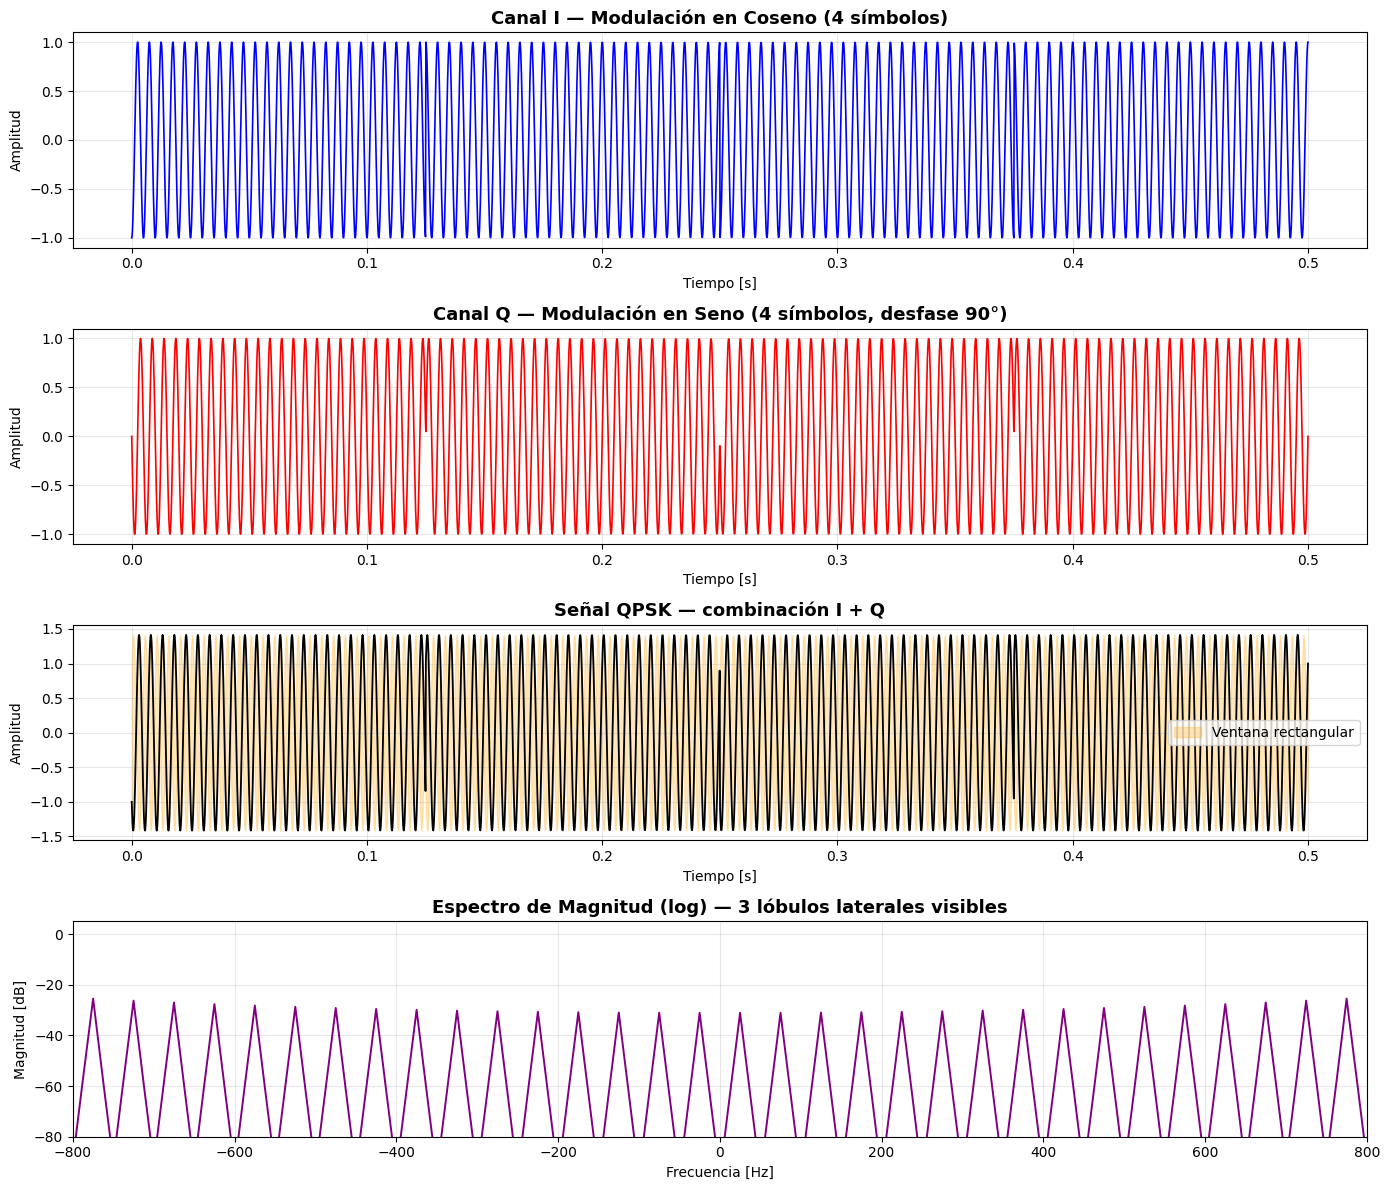

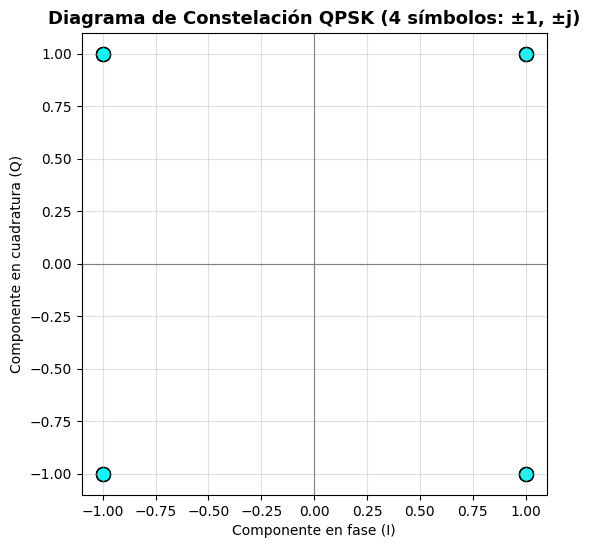


Número de símbolos totales: 8
Símbolos por canal: 4
Tipo de modulación: QPSK (4 símbolos: ±1, ±j)
Frecuencia portadora fc = 200 Hz
Duración de símbolo Ts = 0.125 s
Espaciado entre lóbulos Δf = 8.00 Hz
Frecuencia del lóbulo principal ≈ -1275.00 Hz


In [44]:
# ================================================================
# 🔹 QPSK (8 símbolos) con 4 pulsos por canal, ventana rectangular
# ================================================================
import numpy as np
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------
# PARÁMETROS PRINCIPALES
# ------------------------------------------------
fs = 40000       # Frecuencia de muestreo [Hz]
Ts = 0.125       # Duración de símbolo [s]
fc = 200         # Frecuencia portadora [Hz]
Ns = 800         # Muestras por símbolo
N_sym = 8        # Número total de símbolos (4 en I, 4 en Q)

# ------------------------------------------------
# TRAMA DE DATOS QPSK
# ------------------------------------------------
# 8 símbolos: 4 asignados al canal I y 4 al canal Q
bits_I = np.array([0, 1, 0, 1])  # 4 bits para canal I
bits_Q = np.array([0, 1, 0, 1])  # 4 bits para canal Q

# Mapas QPSK: 0 → -1, 1 → +1
mapa = {0: -1, 1: 1}
I_levels = np.array([mapa[b] for b in bits_I])
Q_levels = np.array([mapa[b] for b in bits_Q])

# ------------------------------------------------
# TIEMPO Y PULSO RECTANGULAR
# ------------------------------------------------
T_total = N_sym * Ts / 2  # 4 símbolos en cada canal → 4*Ts = total
t = torch.linspace(0, T_total, N_sym * Ns // 2)
rect_pulse = torch.ones(Ns)  # Pulso rectangular

# ------------------------------------------------
# GENERACIÓN DE CANALES I y Q
# ------------------------------------------------
I_signal = torch.zeros_like(t)
Q_signal = torch.zeros_like(t)

for i in range(len(I_levels)):
    t_i = t[i*Ns:(i+1)*Ns]
    pulse = rect_pulse
    I_signal[i*Ns:(i+1)*Ns] = I_levels[i] * torch.cos(2*np.pi*fc*t_i) * pulse
    Q_signal[i*Ns:(i+1)*Ns] = Q_levels[i] * torch.sin(2*np.pi*fc*t_i) * pulse

# Señal total combinada (QPSK)
signal_total = I_signal + Q_signal

# ------------------------------------------------
# FFT Y ESPECTRO
# ------------------------------------------------
N = len(signal_total)
S = np.fft.fftshift(np.fft.fft(signal_total))
f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
S_mag = np.abs(S) / np.max(np.abs(S))
S_db = 20 * np.log10(S_mag + 1e-12)

# ------------------------------------------------
# CÁLCULOS DE LÓBULOS
# ------------------------------------------------
main_idx = np.argmax(S_mag)
main_freq = f[main_idx]
df = 1 / Ts  # separación de lóbulos
lobes = [main_freq + k * df for k in range(-3, 4)]

# ------------------------------------------------
# VISUALIZACIÓN TEMPORAL Y ESPECTRAL
# ------------------------------------------------
plt.figure(figsize=(14, 12))

# 1️⃣ Canal I
plt.subplot(4, 1, 1)
plt.plot(t, I_signal, color='blue', linewidth=1.2)
plt.title('Canal I — Modulación en Coseno (4 símbolos)', fontsize=13, fontweight='bold')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)

# 2️⃣ Canal Q
plt.subplot(4, 1, 2)
plt.plot(t, Q_signal, color='red', linewidth=1.2)
plt.title('Canal Q — Modulación en Seno (4 símbolos, desfase 90°)', fontsize=13, fontweight='bold')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)

# 3️⃣ Señal combinada (QPSK)
plt.subplot(4, 1, 3)
plt.plot(t, signal_total, color='black', linewidth=1.3)
plt.fill_between(
    t,
    np.abs(signal_total),
    -np.abs(signal_total),
    color='orange',
    alpha=0.25,
    label='Ventana rectangular'
)
plt.title('Señal QPSK — combinación I + Q', fontsize=13, fontweight='bold')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

# 4️⃣ Espectro en escala logarítmica
plt.subplot(4, 1, 4)
plt.plot(f, S_db, color='purple', linewidth=1.4)
for lf in lobes:
    plt.axvline(lf, color='gray', linestyle='--', alpha=0.5)
plt.title('Espectro de Magnitud (log) — 3 lóbulos laterales visibles', fontsize=13, fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.grid(True, which='both', alpha=0.3)
plt.xlim([-800, 800])
plt.ylim([-80, 5])
plt.tight_layout()
plt.show()

# ------------------------------------------------
# DIAGRAMA DE CONSTELACIÓN QPSK
# ------------------------------------------------
plt.figure(figsize=(6, 6))
const_points = [complex(i, q) for i in I_levels for q in Q_levels]
plt.scatter(np.real(const_points), np.imag(const_points), color='cyan', s=100, edgecolors='k')
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title('Diagrama de Constelación QPSK (4 símbolos: ±1, ±j)', fontsize=13, fontweight='bold')
plt.xlabel('Componente en fase (I)')
plt.ylabel('Componente en cuadratura (Q)')
plt.grid(True, alpha=0.4)
plt.show()

# ------------------------------------------------
# IMPRESIÓN DE PARÁMETROS CALCULADOS
# ------------------------------------------------
print(f"\nNúmero de símbolos totales: {N_sym}")
print(f"Símbolos por canal: {len(I_levels)}")
print(f"Tipo de modulación: QPSK (4 símbolos: ±1, ±j)")
print(f"Frecuencia portadora fc = {fc} Hz")
print(f"Duración de símbolo Ts = {Ts} s")
print(f"Espaciado entre lóbulos Δf = {df:.2f} Hz")
print(f"Frecuencia del lóbulo principal ≈ {main_freq:.2f} Hz")


##  Análisis de la Modulación QAM con (Raised Cosine)

Este código o simulación muestra los fundamentos de la Modulación de Amplitud en Cuadratura (QAM) con conformación de pulsos mediante el filtro Raised Cosine, esencial para el control del espectro y la minimización de la Interferencia Intersimbólica (ISI).

---

### **Muestra del Código y Componentes**

| Característica | Descripción |
| :--- | :--- |
| **Canal I y Q** | Señales en cuadratura ($90^\circ$ de desfase). |
| **Señal QAM** | Señal modulada resultante. |
| **Envolvente** | **Raised Cosine** ($p(t)$), filtro conformador de pulso. |
| **Espectro** | Representación logarítmica (en dB) mostrando el efecto del *roll-off* ($\alpha$). |

---

### **Calibración Dinámica de Parámetros**

| Parámetro | Efecto en la Señal |
| :--- | :--- |
| $\alpha$ (Roll-off) | Factor que suaviza la transición del pulso; **controla el ancho de banda** y la atenuación de los lóbulos laterales. |
| $\beta$ (Escala del Pulso) | Escala el ancho temporal (afecta la concentración espectral). |
| $f_c$ (Frecuencia Portadora) | Frecuencia central de la señal (ajusta la **posición del espectro**). |
| $a_i'$ ($d_{ic}$) | Trama de **símbolos complejos** (p. ej., $\{-1, -j, 1, j\}$). |

---

### **Interpretación Técnica (Ortogonalidad y Conformación)**

El **Canal I** lleva la componente $\cos(\omega_c t)$ y el **Canal Q** lleva la componente $\sin(\omega_c t)$, desfasadas $90^\circ$. La condición de **ortogonalidad** se cumple:

$$
\int_0^T \cos(\omega_c t)\sin(\omega_c t)\,dt = 0
$$

El filtro **Raised Cosine** $p(t)$ elimina el ISI (Interferencia Intersimbólica) al asegurar que el pulso tenga cruces por cero en los instantes de muestreo de los símbolos vecinos ($t = \pm k T_s, k \in \mathbb{Z}^+$).

---

### **EXPLICACIÓN MATEMÁTICA**

#### **Símbolos QAM**

Los símbolos complejos cuaternarios (4-QAM/QPSK) son:
$$
a_i' \in \{-1, -j, 1, j\}
$$
donde el eje real es el Canal I y el imaginario es el Canal Q.

#### **Canales en Cuadratura (I y Q)**

* **Canal I:** $I(t) = a_{i,\text{real}} \cdot \text{rect}_T(t) \cdot \cos(2\pi f_c t)$
* **Canal Q:** $Q(t) = a_{i,\text{imag}} \cdot \text{rect}_T(t) \cdot \sin(2\pi f_c t)$

#### **Señal Total Modulada (Conformación de Pulso)**

La señal total $s(t)$ es la suma ponderada por los símbolos $a_i'$ de pulsos $p(t)$ (Raised Cosine) desplazados en el tiempo:
$$
s(t) = \sum_{i=0}^{N-1} a_i' \, p(t - iT_s) \cos(2\pi f_c t)
$$

#### **Pulso Coseno Alzado (Raised Cosine Pulse)**

La definición del pulso $p(t)$, donde $\alpha$ es el factor de *roll-off*:
$$
p(t) = \frac{\sin(\pi t / T_s)}{\pi t / T_s} \cdot \frac{\cos(\pi \alpha t / T_s)}{1 - (2\alpha t / T_s)^2}
$$

#### **Espectro (FFT normalizada en dB)**

La magnitud del espectro $|S(f)|_{\text{dB}}$ para visualizar el control de ancho de banda:
$$
|S(f)|_{\text{dB}} = 20 \log_{10}\left(\frac{|FFT(s(t))|}{\max|FFT(s(t))|}\right)
$$

#### **Métricas Espectrales**

* **Espaciado entre lóbulos:** Intervalo entre el lóbulo principal y los secundarios:
    $$
    \Delta f = \frac{1}{T_s}
    $$
* **Ancho de banda -3 dB:** Medida del ancho de banda donde el espectro cae $3$ dB respecto al máximo. El ancho de banda nulo es $B = \frac{1}{2T_s}(1+\alpha)$.

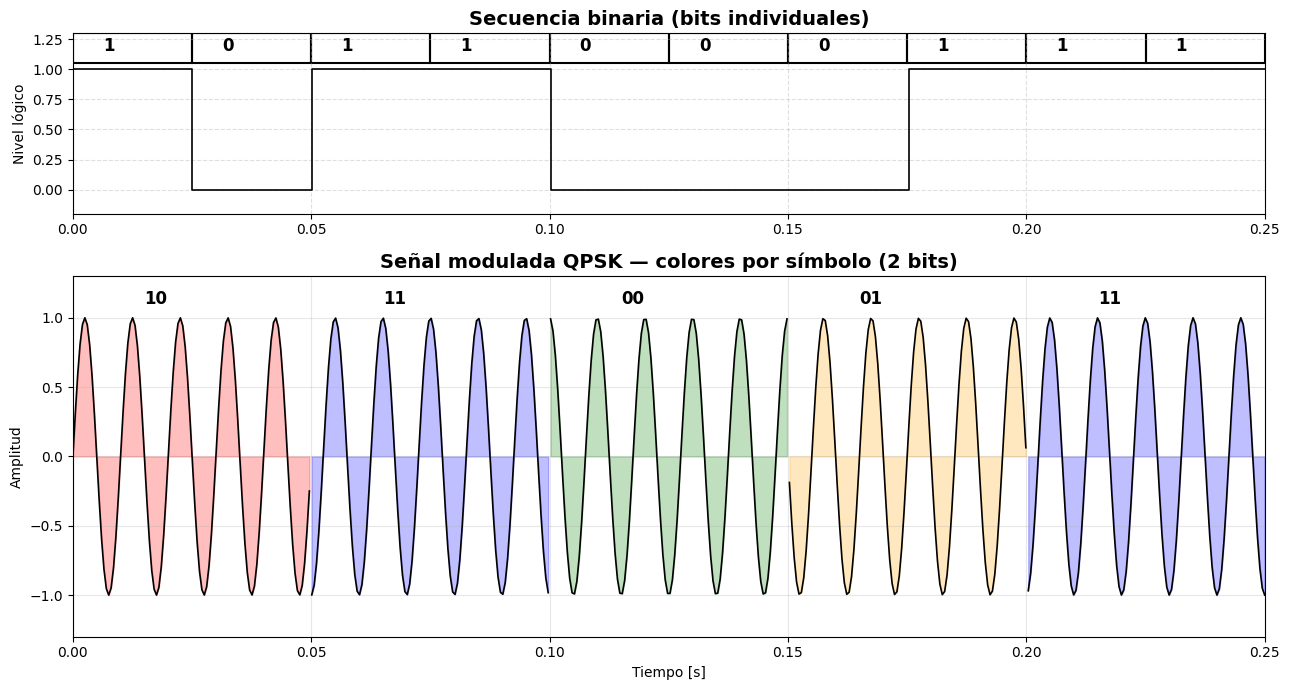

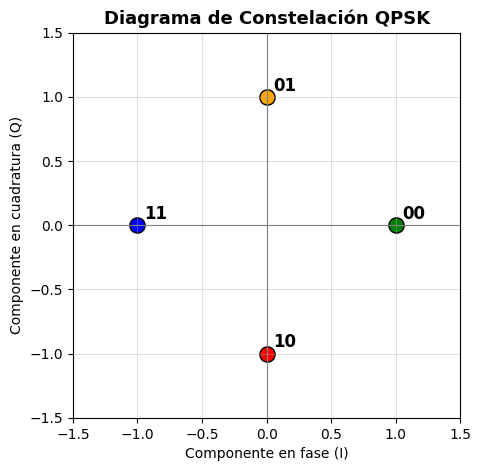

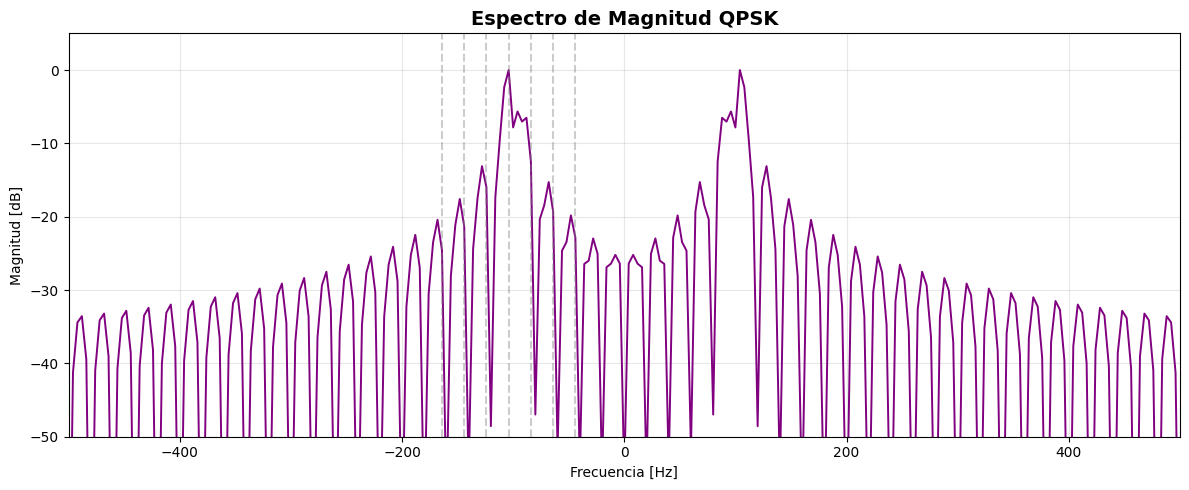

=== Mapeo QPSK ===
Bits (0, 0) → Fase   0.0°
Bits (0, 1) → Fase  90.0°
Bits (1, 1) → Fase 180.0°
Bits (1, 0) → Fase 270.0°

Secuencia transmitida: [1 0 1 1 0 0 0 1 1 1]
Símbolos (pares): [[1, 0], [1, 1], [0, 0], [0, 1], [1, 1]]

Lóbulo principal en -104.00 Hz
Espaciado Δf = 20.00 Hz


In [45]:
# ================================================================
# 🔹 VISUALIZACIÓN EDUCATIVA COMPLETA DE QPSK (BITS + SEÑAL + CONSTELACIÓN + ESPECTRO)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ------------------------------------------------
# PARÁMETROS
# ------------------------------------------------
fs = 2000           # Frecuencia de muestreo [Hz]
fc = 100            # Frecuencia portadora [Hz]
Tb = 0.025          # Duración de bit [s]
Ts = 2 * Tb         # Duración por símbolo (2 bits)
bits = np.array([1,0, 1,1, 0,0, 0,1, 1,1])  # Secuencia de 10 bits (5 símbolos)
Ns_bit = int(fs * Tb)
Ns_sym = int(fs * Ts)

# ------------------------------------------------
# AGRUPACIÓN DE BITS EN PARES (Símbolos QPSK)
# ------------------------------------------------
symbols = bits.reshape(-1, 2)
mapping = {
    (0,0): 0,          # Fase 0°
    (0,1): np.pi/2,    # Fase 90°
    (1,1): np.pi,      # Fase 180°
    (1,0): 3*np.pi/2   # Fase 270°
}
color_map = {(1,0): 'red', (1,1): 'blue', (0,0): 'green', (0,1): 'orange'}

# ------------------------------------------------
# GENERACIÓN DE SEÑALES
# ------------------------------------------------
# Señal binaria (rectangular)
t_bits = np.linspace(0, Tb * len(bits), Ns_bit * len(bits))
bit_signal = np.repeat(bits, Ns_bit)

# Señal QPSK modulada
t_total = np.linspace(0, Ts * len(symbols), Ns_sym * len(symbols))
signal = np.zeros_like(t_total)
for i, sym in enumerate(symbols):
    phi = mapping[tuple(sym)]
    t = t_total[i*Ns_sym:(i+1)*Ns_sym]
    signal[i*Ns_sym:(i+1)*Ns_sym] = np.cos(2*np.pi*fc*t + phi)

# ================================================================
# 🔹 FIGURA 1: SECUENCIA BINARIA + SEÑAL QPSK
# ================================================================
fig, axs = plt.subplots(2, 1, figsize=(13, 7), gridspec_kw={'height_ratios': [1, 2]})
plt.subplots_adjust(hspace=0.35)

# ------------------------------------------------
# 🔸 Gráfica superior: SECUENCIA BINARIA RECTANGULAR
# ------------------------------------------------
axs[0].step(t_bits, bit_signal, where='post', color='k', linewidth=1.2)
axs[0].set_ylim([-0.2, 1.3])
axs[0].set_xlim([0, len(bits)*Tb])
axs[0].set_title("Secuencia binaria (bits individuales)", fontsize=14, fontweight='bold')
axs[0].set_ylabel("Nivel lógico")
axs[0].grid(True, ls='--', alpha=0.4)

# Dibujar cuadros y etiquetas sobre cada bit
for i, b in enumerate(bits):
    axs[0].add_patch(Rectangle((i*Tb, 1.05), Tb, 0.25, fill=False, edgecolor='k', linewidth=1.5))
    axs[0].text(i*Tb + Tb/2 - 0.005, 1.15, str(b), fontsize=12, fontweight='bold', ha='center')

# ------------------------------------------------
# 🔸 Gráfica inferior: SEÑAL QPSK MODULADA
# ------------------------------------------------
axs[1].set_title("Señal modulada QPSK — colores por símbolo (2 bits)", fontsize=14, fontweight='bold')
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_ylabel("Amplitud")
axs[1].grid(True, alpha=0.3)

for i, sym in enumerate(symbols):
    t = t_total[i*Ns_sym:(i+1)*Ns_sym]
    axs[1].plot(t, signal[i*Ns_sym:(i+1)*Ns_sym], color='k', linewidth=1.2)
    axs[1].fill_between(t, signal[i*Ns_sym:(i+1)*Ns_sym], 0, color=color_map[tuple(sym)], alpha=0.25)
    axs[1].text(i*Ts + Ts/2 - 0.01, 1.1, f"{sym[0]}{sym[1]}", fontsize=12, fontweight='bold')

axs[1].set_ylim([-1.3, 1.3])
axs[1].set_xlim([0, len(symbols)*Ts])

plt.tight_layout()
plt.show()

# ================================================================
# 🔹 DIAGRAMA DE CONSTELACIÓN
# ================================================================
plt.figure(figsize=(5,5))
plt.title("Diagrama de Constelación QPSK", fontsize=13, fontweight='bold')
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)

const_points = {
    "00": (1, 0),
    "01": (0, 1),
    "11": (-1, 0),
    "10": (0, -1)
}
for label, (x, y) in const_points.items():
    plt.scatter(x, y, s=120, color=color_map[(int(label[0]), int(label[1]))], edgecolors='k')
    plt.text(x+0.05, y+0.05, label, fontsize=12, fontweight='bold')

plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.xlabel("Componente en fase (I)")
plt.ylabel("Componente en cuadratura (Q)")
plt.grid(True, alpha=0.4)
plt.show()

# ================================================================
# 🔹 ESPECTRO DE MAGNITUD
# ================================================================
N = len(signal)
S = np.fft.fftshift(np.fft.fft(signal))
f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
S_mag = np.abs(S) / np.max(np.abs(S))
S_db = 20 * np.log10(S_mag + 1e-12)

plt.figure(figsize=(12,5))
plt.plot(f, S_db, color='purple', linewidth=1.4)
plt.title('Espectro de Magnitud QPSK', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.grid(True, which='both', alpha=0.3)

df = 1 / Ts
main_idx = np.argmax(S_mag)
main_freq = f[main_idx]
lobes = [main_freq + k * df for k in range(-3, 4)]
for lf in lobes:
    plt.axvline(lf, color='gray', linestyle='--', alpha=0.4)

plt.xlim([-500, 500])
plt.ylim([-50, 5])
plt.tight_layout()
plt.show()

# ================================================================
# 🔹 INFORMACIÓN IMPRESA
# ================================================================
print("=== Mapeo QPSK ===")
for k, v in mapping.items():
    print(f"Bits {k} → Fase {np.degrees(v):>5.1f}°")
print(f"\nSecuencia transmitida: {bits}")
print(f"Símbolos (pares): {symbols.tolist()}")
print(f"\nLóbulo principal en {main_freq:.2f} Hz")
print(f"Espaciado Δf = {df:.2f} Hz")


#**oscilogramas con la evolución del espectro**

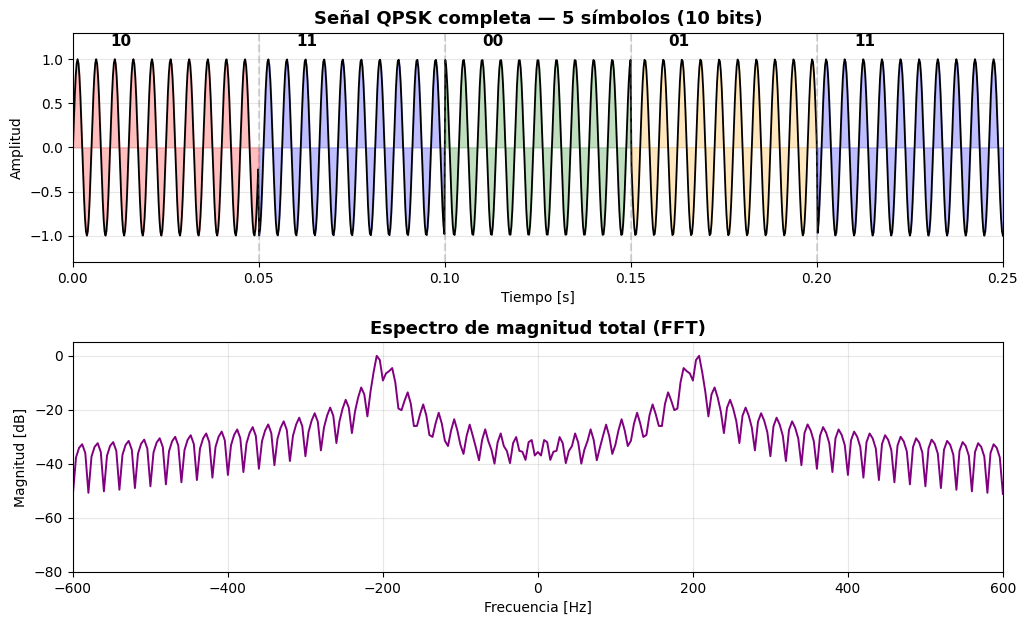

In [46]:
# ================================================================
# 🔹 EVOLUCIÓN TEMPORAL Y ESPECTRAL DE UNA SEÑAL QPSK (versión visible)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ------------------------------------------------
# ⚙️ PARÁMETROS
# ------------------------------------------------
fs = 4000          # Frecuencia de muestreo [Hz]
fc = 200           # Frecuencia portadora [Hz]
Tb = 0.025         # Duración por bit [s]
Ts = 2 * Tb        # Duración por símbolo (2 bits)
bits = np.array([1,0, 1,1, 0,0, 0,1, 1,1])  # 10 bits → 5 símbolos

Ns_bit = int(fs * Tb)
Ns_sym = int(fs * Ts)

# ------------------------------------------------
# MAPEADO DE FASE QPSK
# ------------------------------------------------
mapping = {
    (0,0): 0,          # 0°
    (0,1): np.pi/2,    # 90°
    (1,1): np.pi,      # 180°
    (1,0): 3*np.pi/2   # 270°
}
color_map = {(1,0): 'red', (1,1): 'blue', (0,0): 'green', (0,1): 'orange'}

# Agrupar bits en pares (símbolos)
symbols = bits.reshape(-1, 2)

# ------------------------------------------------
# CONSTRUCCIÓN DE LA SEÑAL COMPLETA
# ------------------------------------------------
t_total = np.linspace(0, Ts * len(symbols), Ns_sym * len(symbols))
signal = np.zeros_like(t_total)

for i, sym in enumerate(symbols):
    phi = mapping[tuple(sym)]
    t = t_total[i*Ns_sym:(i+1)*Ns_sym]
    signal[i*Ns_sym:(i+1)*Ns_sym] = np.cos(2*np.pi*fc*t + phi)

# ------------------------------------------------
# 🔹 GRÁFICA ESTÁTICA INICIAL (vista general)
# ------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))
plt.subplots_adjust(hspace=0.35)

# Señal QPSK en el tiempo
ax1.plot(t_total, signal, color='k', lw=1.3)
ax1.set_title("Señal QPSK completa — 5 símbolos (10 bits)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud")
ax1.set_xlim(0, len(symbols)*Ts)
ax1.set_ylim(-1.3, 1.3)
ax1.grid(True, alpha=0.3)

# Colorear cada símbolo
for i, sym in enumerate(symbols):
    t = t_total[i*Ns_sym:(i+1)*Ns_sym]
    ax1.fill_between(t, signal[i*Ns_sym:(i+1)*Ns_sym], 0,
                     color=color_map[tuple(sym)], alpha=0.25)
    ax1.text(i*Ts + Ts/2 - 0.015, 1.15, f"{sym[0]}{sym[1]}", fontsize=11, fontweight='bold')
    ax1.axvline(i*Ts, color='gray', linestyle='--', alpha=0.3)

# Espectro general
N = len(signal)
S = np.fft.fftshift(np.fft.fft(signal * np.hanning(N)))
f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
S_mag = np.abs(S) / np.max(np.abs(S))
S_db = 20 * np.log10(S_mag + 1e-12)
ax2.plot(f, S_db, color='purple', lw=1.4)
ax2.set_title("Espectro de magnitud total (FFT)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Magnitud [dB]")
ax2.set_xlim(-600, 600)
ax2.set_ylim(-80, 5)
ax2.grid(True, which='both', alpha=0.3)

plt.show()

# ------------------------------------------------
# 🔹 ANIMACIÓN: EVOLUCIÓN TEMPORAL Y ESPECTRAL
# ------------------------------------------------
fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))
plt.subplots_adjust(hspace=0.35)

# Subplot 1 — Señal temporal
ax1.set_title("Evolución temporal de la señal QPSK", fontsize=13, fontweight='bold')
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud")
ax1.set_xlim(0, len(symbols)*Ts)
ax1.set_ylim(-1.3, 1.3)
ax1.grid(True, alpha=0.3)
line_time, = ax1.plot([], [], color='k', lw=1.3)
fill_time = None

# Subplot 2 — Espectro FFT
ax2.set_title("Evolución del espectro de magnitud (FFT)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Magnitud [dB]")
ax2.set_xlim(-600, 600)
ax2.set_ylim(-50, 5)
ax2.grid(True, which='both', alpha=0.3)
line_freq, = ax2.plot([], [], color='purple', lw=1.4)

def update(frame):
    global fill_time
    if fill_time:
        fill_time.remove()

    # Construir señal parcial
    signal_partial = np.zeros_like(signal)
    for i in range(frame+1):
        phi = mapping[tuple(symbols[i])]
        t = t_total[i*Ns_sym:(i+1)*Ns_sym]
        signal_partial[i*Ns_sym:(i+1)*Ns_sym] = np.cos(2*np.pi*fc*t + phi)

    # Actualizar señal en el tiempo
    line_time.set_data(t_total, signal_partial)
    color = color_map[tuple(symbols[frame])]
    t = t_total[frame*Ns_sym:(frame+1)*Ns_sym]
    fill_time = ax1.fill_between(t, signal_partial[frame*Ns_sym:(frame+1)*Ns_sym], 0, color=color, alpha=0.25)
    ax1.axvline((frame+1)*Ts, color='gray', ls='--', alpha=0.3)

    # Calcular FFT actual
    N = len(signal_partial)
    S = np.fft.fftshift(np.fft.fft(signal_partial * np.hanning(N)))
    f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
    S_mag = np.abs(S) / np.max(np.abs(S))
    S_db = 20 * np.log10(S_mag + 1e-12)
    line_freq.set_data(f, S_db)

    ax1.set_title(f"Símbolo {frame+1}/{len(symbols)} — bits {symbols[frame][0]}{symbols[frame][1]}", fontsize=13)
    return line_time, line_freq, fill_time

# Crear animación
anim = FuncAnimation(fig2, update, frames=len(symbols), interval=1500, blit=False, repeat=True)

# Mostrar animación
plt.close(fig2)
HTML(anim.to_jshtml())


#  Procedimiento Matemático y Explicación de la Simulación QPSK Rectangular



---

## 1. Especificación de la Trama y Mapeo QPSK

Se inicia con una secuencia de bits $d = [d_0,d_1,\dots,d_{N-1}]$, agrupada en pares $(b_0,b_1)$ para generar $M$ símbolos.

**Mapeo de bits a fase (QPSK - Convención Gray):**
$$
\text{Mapeo de bits a fase (QPSK):}\quad
\begin{cases}
(0,0) \mapsto \varphi = 0,\\[4pt]
(0,1) \mapsto \varphi = \tfrac{\pi}{2},\\[4pt]
(1,1) \mapsto \varphi = \pi,\\[4pt]
(1,0) \mapsto \varphi = \tfrac{3\pi}{2}.
\end{cases}
$$
Cada símbolo tiene una duración $T_s$, donde $T_s = 2T_b$ ($T_b$ es la duración de bit).

---

## 2. Pulso Base y Envolvente Rectangular

El pulso rectangular unitario $\operatorname{rect}_{T_s}(t)$ define la forma del símbolo en el tiempo:
$$
\operatorname{rect}_{T_s}(t) =
\begin{cases}
1, & 0 \le t < T_s,\\
0, & \text{en otro caso.}
\end{cases}
$$
En la señal total, esto se aplica por símbolo como una envolvente $v_i(t)$.

---

## 3. Señal Modulada por Símbolo (QPSK)

Para el $i$-ésimo símbolo (con fase $\varphi_i$), la señal local en $t\in[0,T_s)$ es:
$$
s_i(t) \;=\; v_i(t)\,\cos\!\big(\omega_0 t + \varphi_i\big),
\qquad \omega_0 = 2\pi f_c.
$$
La **señal transmitida total** (concatenación de $M$ símbolos) es:
$$
s_{\text{total}}(t) \;=\; \sum_{i=0}^{M-1} s_i(t - iT_s) .
$$
*Nota: La portadora $\cos(\omega_0 t)$ mantiene continuidad temporal a través de los símbolos.*

---

## 4. Ventanas para Mitigar el Spectral Leakage

Para reducir el *spectral leakage* (efecto de truncamiento), se aplica la ventana Hann al vector de muestras $x[n]$ antes de la FFT:
$$
x_w[n] = x[n]\cdot w[n],\qquad w[n] = 0.5 \Big(1 - \cos\frac{2\pi n}{N-1}\Big).
$$

---

## 5. Transformada Discreta (FFT) y Eje de Frecuencias

Se calcula la DFT (FFT) de $N$ puntos del vector $x_w[n]$:
$$
X[k] = \sum_{n=0}^{N-1} x_w[n]\; e^{-j 2\pi \frac{k n}{N}},\qquad k=0,\dots,N-1.
$$
El eje de frecuencias, centrado en $0$ Hz (usando $\operatorname{fftshift}$), es:
$$
f[k] = \frac{k}{N}\,f_s - f_s/2 \quad\text{(con } f_s \text{ como frecuencia de muestreo)}.
$$

---

## 6. Normalización y Conversión a Decibelios (dB)

**Magnitud Normalizada:** El pico máximo se lleva a la unidad.
$$
|X_{\text{norm}}(f)| = \frac{|X(f)|}{\max_f |X(f)|}.
$$
**Magnitud en dB:**
$$
X_{\mathrm{dB}}(f) \;=\; 20\log_{10}\big(|X_{\text{norm}}(f)| + \varepsilon\big),\qquad \varepsilon \approx 10^{-12}.
$$
El pico del espectro resultante será $0\ \mathrm{dB}$.

---

## 7. Ceros Teóricos y Lóbulos Laterales (Referencia Sinc)

La transformada del pulso rectangular $T_s$ (en banda base) es una función $\operatorname{sinc}$:
$$
S(f) = T_s \cdot \operatorname{sinc}(fT_s) = T_s\cdot \frac{\sin(\pi f T_s)}{\pi f T_s}.
$$
Los ceros ocurren en múltiplos de $1/T_s$:
$$
f_n = \frac{n}{T_s},\quad n=\pm1,\pm2,\dots
$$
La amplitud teórica del **primer lóbulo lateral** (respecto al principal) es:
$$
A_1 = 20\log_{10}\left(\frac{\sin(\tfrac{3\pi}{2})}{\tfrac{3\pi}{2}}\right) \approx -13.26\ \mathrm{dB}.
$$

---

## 8. Parámetros de Espaciado

* **Espaciado Angular Básico:** $\Delta\omega = \frac{2\pi}{T_s}.$
* **Espaciado en Frecuencia:** $\Delta f = \frac{\Delta\omega}{2\pi} = \frac{1}{T_s}.$
* **Constante Derivada (enunciado):** $\Delta_c' = 3\,\Delta\omega.$

---

## 9. Evolución Espectral (Análisis Dinámico)

La animación muestra la convergencia del espectro al calcular la FFT de una señal parcial $s^{(m)}(t)$:
$$
s^{(m)}(t) = \sum_{i=0}^{m-1} s_i(t - iT_s).
$$
Con $m$ creciente, la transformada $|S^{(m)}(f)|_{\mathrm{dB}}$ se estabiliza, **definiendo el lóbulo principal** y mostrando la atenuación de los **lóbulos laterales**.

---

## 10. Comparación con Raised Cosine (Nota)

El pulso **Raised Cosine** (RC) con factor de *roll-off* $\alpha$ reduce drásticamente la energía de los lóbulos laterales lejanos. Su ancho de banda de ocupación es:
$$
B_{\text{RC}} \;=\; \frac{1+\alpha}{T_s}
$$

---

## 12. Resumen

* Señal QPSK modulada por **pulsos rectangulares**.
* Se aplica **ventana Hann** antes de la FFT para atenuar el *spectral leakage*.
* El espectro se **normaliza a $0\ \mathrm{dB}$** para un análisis claro de lóbulos laterales.
* Los ceros teóricos están en $f_n = n/T_s$ y el **primer lóbulo lateral es $\approx -13.26\ \mathrm{dB}$** (referencia fundamental del pulso rectangular/sinc).
* La simulación muestra la **convergencia espectral** al concatenar símbolos, revelando el ancho de banda y el espaciado $\Delta f = 1/T_s$.

#**Modulación OQPSK**

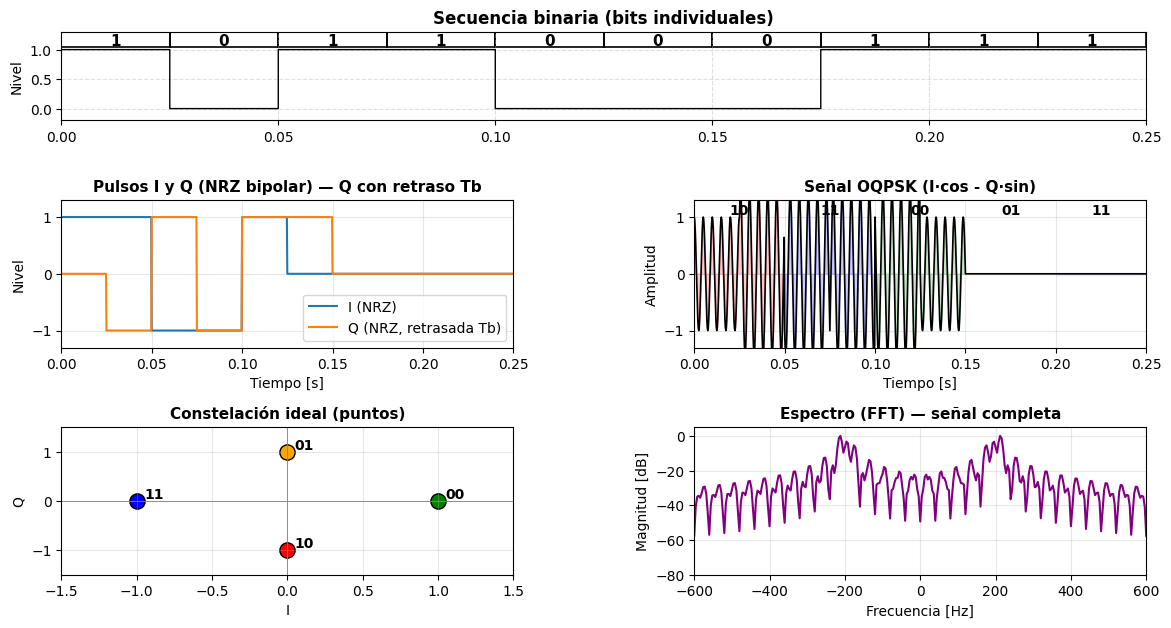

In [47]:
# ================================================================
# OQPSK - Evolución temporal y espectral (bits, I/Q offset, oscilograma y FFT)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Parámetros configurables
# -----------------------------
fs = 4000            # frecuencia de muestreo [Hz] (ajustable)
fc = 200             # frecuencia portadora [Hz]
Tb = 0.025           # duración de bit [s] (ej. 25 ms)
Ts = 2 * Tb          # símbolo OQPSK (2 bits) -> Ts = 2*Tb
# Secuencia de bits (longitud par). Cambiar aquí si se desea.
bits = np.array([1,0, 1,1, 0,0, 0,1, 1,1], dtype=int)  # 10 bits -> 5 símbolos
# -----------------------------
assert len(bits) % 2 == 0, "La longitud de bits debe ser par."

# -----------------------------
# parámetros derivados
# -----------------------------
N_bits = len(bits)
N_symbols = N_bits // 2
Ns_bit = int(np.round(fs * Tb))      # muestras por bit
Ns_sym = int(np.round(fs * Ts))      # muestras por símbolo (== 2*Ns_bit)
t_bits = np.linspace(0, Tb * N_bits, Ns_bit * N_bits, endpoint=False)   # tiempo para bits (rect)
t_total = np.linspace(0, Ts * N_symbols, Ns_sym * N_symbols, endpoint=False)  # tiempo para señal completa

# -----------------------------
# Mapeo simple de bits a niveles (NRZ bipolar) para I y Q
# OQPSK: I toma los bits pares (b0, b2,...) y Q toma los bits impares (b1, b3,...),
# pero Q se transmite con un retardo Tb (offset) para evitar transiciones de fase de 180°
# -----------------------------
# niveles: 0 -> -1, 1 -> +1
def bit_to_level(b):
    return 2*b - 1

# Stream I: bits in even positions of pair (b0, b2, ...)? We'll map as follows:
# For OQPSK common implementation: split bits into I and Q sequences:
# - I_bits = bits[0], bits[2], bits[4], ...
# - Q_bits = bits[1], bits[3], bits[5], ...
I_bits = bits[0::2]
Q_bits = bits[1::2]
# convert to levels
I_levels = bit_to_level(I_bits)
Q_levels = bit_to_level(Q_bits)

# Build baseband pulse trains (rectangular pulses of duration Tb each) sampled at fs
I_base = np.repeat(I_levels, Ns_bit)    # length N_bits/2 * Ns_bit
Q_base = np.repeat(Q_levels, Ns_bit)

# For OQPSK, Q is delayed by exactly Tb (Ns_bit samples). We'll pad front with zeros and trim to total length.
# Build time arrays aligned to t_total length:
N_total = len(t_total)
I_samples = np.zeros(N_total)
Q_samples = np.zeros(N_total)

# Fill I_samples: successive bits of I_levels, each duration Tb, but aligned to symbol grid (two bits -> Ts).
# Because t_total is multiple of Ns_sym and Ns_sym = 2*Ns_bit, we fill in segments of Ns_bit for each I bit located at sample indices:
for i, level in enumerate(I_levels):
    start_idx = i * Ns_bit      # I bits start at 0, Tb, 2*Tb, ...
    end_idx = start_idx + Ns_bit
    if end_idx <= N_total:
        I_samples[start_idx:end_idx] = level
    else:
        I_samples[start_idx:N_total] = level

# Fill Q_samples but delayed by Ns_bit (Tb)
for i, level in enumerate(Q_levels):
    start_idx = i * Ns_bit + Ns_bit   # delay by one Tb
    end_idx = start_idx + Ns_bit
    if start_idx < N_total:
        # clip if end_idx out of range
        end_idx_c = min(end_idx, N_total)
        Q_samples[start_idx:end_idx_c] = level

# Now construct the passband OQPSK signal:
# s(t) = I(t) * cos(2π f_c t) - Q(t) * sin(2π f_c t)   (convention; minus sign or plus is a convention)
carrier_cos = np.cos(2 * np.pi * fc * t_total)
carrier_sin = np.sin(2 * np.pi * fc * t_total)
s_oqpsk = I_samples * carrier_cos - Q_samples * carrier_sin

# -----------------------------
# Función FFT (ventana Hann) para una señal
# -----------------------------
def compute_fft(signal, fs):
    N = len(signal)
    window = np.hanning(N)
    S = np.fft.fftshift(np.fft.fft(signal * window, n=N))
    f = np.fft.fftshift(np.fft.fftfreq(N, d=1.0/fs))
    S_mag = np.abs(S)
    S_db = 20 * np.log10(S_mag / (S_mag.max() + 1e-12) + 1e-12)
    return f, S_db

# FFT total
f_tot, S_tot_db = compute_fft(s_oqpsk, fs)

# -----------------------------
# GRÁFICOS ESTÁTICOS: Bits (arriba), I & Q pulses + signal (medio), constelación, espectro (abajo)
# -----------------------------
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(4, 2, height_ratios=[0.6, 1.0, 1.0, 1.0], hspace=0.6, wspace=0.4)

# 1) bit stream (top full width)
ax_bits = fig.add_subplot(gs[0, :])
ax_bits.step(t_bits, np.repeat(bits, Ns_bit), where='post', color='k', lw=1)
ax_bits.set_ylim(-0.2, 1.3)
ax_bits.set_xlim(0, t_total[-1] + (1/fs))
ax_bits.set_title("Secuencia binaria (bits individuales)", fontsize=12, fontweight='bold')
ax_bits.set_ylabel("Nivel")
ax_bits.grid(True, ls='--', alpha=0.4)
# draw boxes with 0/1 digits
for i, b in enumerate(bits):
    x0 = i * Tb
    ax_bits.add_patch(Rectangle((x0, 1.05), Tb, 0.25, fill=False, edgecolor='k', linewidth=1.2))
    ax_bits.text(x0 + Tb/2, 1.15, str(b), ha='center', va='center', fontsize=11, fontweight='bold')

# 2) I and Q pulses (left column middle)
ax_iq = fig.add_subplot(gs[1, 0])
ax_iq.plot(t_total, I_samples, label='I (NRZ)', color='tab:blue')
ax_iq.plot(t_total, Q_samples, label='Q (NRZ, retrasada Tb)', color='tab:orange')
ax_iq.set_title("Pulsos I y Q (NRZ bipolar) — Q con retraso Tb", fontsize=11, fontweight='bold')
ax_iq.set_xlim(0, t_total[-1] + (1/fs))
ax_iq.set_ylim(-1.3, 1.3)
ax_iq.set_xlabel("Tiempo [s]")
ax_iq.set_ylabel("Nivel")
ax_iq.grid(True, alpha=0.3)
ax_iq.legend()

# 3) OQPSK oscilograma (right column middle)
ax_sig = fig.add_subplot(gs[1, 1])
ax_sig.plot(t_total, s_oqpsk, color='k', lw=1.2)
# color fill per symbol (use pair of bits)
for i in range(N_symbols):
    sym_bits = (bits[2*i], bits[2*i+1])
    # choose color by mapping same as before for visual cue
    cmap = {(1,0): 'red', (1,1): 'blue', (0,0): 'green', (0,1): 'orange'}
    col = cmap.get(sym_bits, 'gray')
    start = i * Ts
    tseg_idx0 = int(np.round(i * Ns_sym))
    tseg_idx1 = int(np.round((i+1) * Ns_sym))
    ax_sig.fill_between(t_total[tseg_idx0:tseg_idx1], s_oqpsk[tseg_idx0:tseg_idx1], 0, color=col, alpha=0.2)
    ax_sig.text(start + Ts/2, 1.05, f"{sym_bits[0]}{sym_bits[1]}", ha='center', fontsize=10, fontweight='bold')
ax_sig.set_title("Señal OQPSK (I·cos - Q·sin)", fontsize=11, fontweight='bold')
ax_sig.set_xlim(0, t_total[-1] + (1/fs))
ax_sig.set_ylim(-1.3, 1.3)
ax_sig.set_xlabel("Tiempo [s]")
ax_sig.set_ylabel("Amplitud")
ax_sig.grid(True, alpha=0.3)

# 4) Constellation (lower left)
ax_const = fig.add_subplot(gs[2, 0])
ax_const.set_title("Constelación ideal (puntos)", fontsize=11, fontweight='bold')
ax_const.axhline(0, color='gray', linewidth=0.6)
ax_const.axvline(0, color='gray', linewidth=0.6)
# ideal points ±1, ±j
points = {'00': (1,0), '01': (0,1), '11': (-1,0), '10': (0,-1)}
for label, (x,y) in points.items():
    ax_const.scatter(x, y, s=120, color=cmap[(int(label[0]), int(label[1]))], edgecolors='k')
    ax_const.text(x+0.05, y+0.05, label, fontsize=10, fontweight='bold')
ax_const.set_xlim(-1.5, 1.5)
ax_const.set_ylim(-1.5, 1.5)
ax_const.set_xlabel("I")
ax_const.set_ylabel("Q")
ax_const.grid(True, alpha=0.3)

# 5) Spectrum (lower right)
ax_spec = fig.add_subplot(gs[2, 1])
ax_spec.plot(f_tot, S_tot_db, color='purple', lw=1.5)
ax_spec.set_title("Espectro (FFT) — señal completa", fontsize=11, fontweight='bold')
ax_spec.set_xlim(-600, 600)
ax_spec.set_ylim(-80, 5)
ax_spec.set_xlabel("Frecuencia [Hz]")
ax_spec.set_ylabel("Magnitud [dB]")
ax_spec.grid(True, which='both', alpha=0.3)

plt.show()

# -----------------------------
# ANIMACIÓN: evolución por bit (mostrar oscilograma parcial y FFT parcial)
# -----------------------------
fig2, (ax_t, ax_f) = plt.subplots(2,1, figsize=(12,6))
plt.subplots_adjust(hspace=0.4)
ax_t.set_xlim(0, t_total[-1] + (1/fs))
ax_t.set_ylim(-1.3, 1.3)
ax_t.set_xlabel("Tiempo [s]")
ax_t.set_ylabel("Amplitud")
ax_t.set_title("Evolución temporal (acumulativa) - OQPSK")

ax_f.set_xlim(-600, 600)
ax_f.set_ylim(-50, 5)
ax_f.set_xlabel("Frecuencia [Hz]")
ax_f.set_ylabel("Magnitud [dB]")
ax_f.set_title("Evolución del espectro (acumulativo)")

line_t, = ax_t.plot([], [], color='k', lw=1.2)
fill_patch = None
line_f, = ax_f.plot([], [], color='purple', lw=1.5)

def update(frame):
    global fill_patch
    # frame goes from 0 to N_bits-1 (we update per bit)
    # Build partial I/Q according to how many bits transmitted so far
    # partial I: fill I_samples up to sample index = frame*Ns_bit + Ns_bit (because bit index)
    n_samples_partial = min((frame+1) * Ns_bit, len(t_total))
    # reconstruct partial I and Q arrays truncated to n_samples_partial
    I_part = np.zeros_like(I_samples)
    Q_part = np.zeros_like(Q_samples)
    I_part[:n_samples_partial] = I_samples[:n_samples_partial]
    Q_part[:n_samples_partial] = Q_samples[:n_samples_partial]
    s_part = I_part * carrier_cos - Q_part * carrier_sin

    # update time plot
    line_t.set_data(t_total, s_part)
    if fill_patch:
        try:
            fill_patch.remove()
        except Exception:
            pass
    # highlight current bit region
    bit_idx = frame
    start_t = bit_idx * Tb
    end_t = start_t + Tb
    # fill current bit region for visibility
    mask = (t_total >= start_t) & (t_total < end_t)
    fill_patch = ax_t.fill_between(t_total[mask], s_part[mask], 0, color='tab:gray', alpha=0.25)

    # update FFT plot for s_part
    f_p, S_p_db = compute_fft(s_part, fs)
    line_f.set_data(f_p, S_p_db)

    ax_t.set_title(f"Evolución temporal (bits transmitidos: {frame+1}/{N_bits})")
    return line_t, line_f, fill_patch

anim = FuncAnimation(fig2, update, frames=N_bits, interval=900, blit=False, repeat=True)

# show animation inline (works in Jupyter/Colab)
plt.close(fig2)
HTML(anim.to_jshtml())


#**OQPSK (Offset Quadrature Phase-Shift Keying)**


---

## 1. Parámetros de Tiempo y Muestreo

Se establecen las relaciones temporales discretas a partir de la frecuencia de muestreo $f_s$:

| Parámetro | Símbolo | Fórmula |
| :--- | :--- | :--- |
| Duración de bit | $T_b$ | |
| Duración de símbolo | $T_s$ | $T_s = 2T_b$ (2 bits/símbolo) |
| Frecuencia de muestreo | $f_s$ | |
| Muestras por bit | $N_{s}^{(b)}$ | $N_{s}^{(b)} = \mathrm{round}(f_s T_b)$ |
| Muestras por símbolo | $N_{s}^{(s)}$ | $N_{s}^{(s)} = 2 N_{s}^{(b)} = f_s T_s$ |

El vector de tiempo discreto es:
$$
t[n] = n\cdot T_{\text{samp}}=\frac{n}{f_s},\qquad n=0,1,\dots,N_{\text{total}}-1.
$$

---

## 2. Mapeo de Bits a Niveles Bipolares (NRZ)

Los bits $b\in\{0,1\}$ se convierten a niveles de amplitud $a\in\{-1,+1\}$ (polar NRZ):
$$
a = 2b - 1.
$$
**Separación de Flujos:** Los bits se dividen en dos flujos baseband que operan a la mitad de la tasa de bits original ($1/T_s$):
* **Flujo I (In-phase):** Bits en posiciones pares ($\{I_k\}$).
* **Flujo Q (Quadrature):** Bits en posiciones impares ($\{Q_k\}$).

Las señales baseband discretas ($I[n]$ y $Q[n]$) se obtienen extendiendo cada nivel por $N_{s}^{(b)}$ muestras (un pulso rectangular de duración $T_b$):
$$
I[n] = I_{\lfloor n / N_{s}^{(b)}\rfloor},\qquad Q[n] = Q_{\lfloor n / N_{s}^{(b)}\rfloor}.
$$

---

## 3. Offset Temporal ($\Delta t = T_b$)

La característica distintiva de OQPSK es el **retraso** de la componente $Q$ en $T_b$ respecto a $I$. Esto se traduce en un desplazamiento de $N_{s}^{(b)}$ muestras en el dominio discreto:
$$
Q_{\text{transmitida}}[n] = Q_{\text{base}}[n - N_{s}^{(b)}].
$$
Este *offset* de medio símbolo asegura que las transiciones de $I$ y $Q$ nunca ocurran al mismo tiempo, limitando el cambio de fase instantáneo a un máximo de $\pm 90^\circ$ (a diferencia de QPSK que permite $180^\circ$), lo que suaviza la envolvente de la señal.

---

## 4. Señal OQPSK en Banda Pasante

La señal modulada en banda pasante $s(t)$ se obtiene combinando los flujos $I$ y $Q$ con portadoras ortogonales ($\cos$ y $\sin$):
$$
s(t) = I(t)\cos(2\pi f_c t) - Q(t)\sin(2\pi f_c t).
$$
En tiempo discreto (muestras $n$):
$$
s[n] = I[n]\cos\!\big(2\pi f_c \tfrac{n}{f_s}\big) - Q[n]\sin\!\big(2\pi f_c \tfrac{n}{f_s}\big).
$$
*Nota: Se usan pulsos rectangulares (NRZ) en $I[n]$ y $Q[n]$ en esta simulación. Usar filtros de pulso como Raised Cosine cambiaría la forma espectral.*

---

## 5. Interpretación de la Constelación y Transiciones

La constelación utilizada asigna los niveles $(\pm 1, 0)$ y $(0, \pm 1)$ a pares de bits.
* **Puntos de Constelación:** Son $\begin{cases} (+1, 0) \leftarrow 00 \\ (-1, 0) \leftarrow 11 \\ (0, +1) \leftarrow 01 \\ (0, -1) \leftarrow 10 \end{cases}$.
* **Transiciones:** En QPSK, un cambio de $180^\circ$ implica que las componentes $I$ y $Q$ cambian simultáneamente de signo (p. ej., de $(+1, +1)$ a $(-1, -1)$), lo que hace que la envolvente pase por cero y genera grandes lóbulos laterales.
* **En OQPSK**, el retraso $T_b$ previene estas transiciones de $180^\circ$ y el paso por cero, manteniendo la envolvente más constante (o al menos minimizando su variación).

---

## 6. Cálculo de la FFT (Ventana y dB)

Para el análisis espectral, se procesa la señal finita $s[n]$:

1.  **Ventana de Hann ($w[n]$):** Aplicada para reducir el *spectral leakage* del truncamiento de la señal:
    $$
    w[n] = 0.5\Big(1 - \cos\!\frac{2\pi n}{N-1}\Big),\quad n=0,\dots,N-1.
    $$

2.  **Transformada Discreta de Fourier (DFT):**
    $$
    S[k] = \sum_{n=0}^{N-1} \big(s[n]\cdot w[n]\big) e^{-j 2\pi \frac{k n}{N}},\qquad k=0,\dots,N-1.
    $$

3.  **Magnitud en dB (Normalizada):** El espectro se normaliza al máximo y se expresa en dB (usando $\varepsilon$ para estabilidad numérica):
    $$
    S_{\text{dB}}[k] = 20\log_{10}\!\Big(\frac{|S[k]|}{\max_k |S[k]| + \varepsilon} + \varepsilon\Big),\qquad \varepsilon \approx 10^{-12}.
    $$
    *El pico máximo del espectro centrado ($\operatorname{fftshift}$) es $0\ \mathrm{dB}$.*

---

## 7. Comportamiento Espectral (NRZ/Rectangular)

Debido al uso de pulsos rectangulares (NRZ) en banda base, la envolvente del espectro en banda pasante estará dominada por el perfil $\operatorname{sinc}$ (sincrónico) desplazado a $\pm f_c$.

* **Ancho de Banda Principal:** $\approx 2/T_b$ o $1/T_s$.
* **Lóbulos Laterales:** Los lóbulos del $\operatorname{sinc}$ se atenúan a razón de $\sim 20\log_{10}(f)$ (o menos si hay ventana), mostrando el primer lóbulo lateral teórico del pulso rectangular a $\approx -13.26\ \mathrm{dB}$.

*El beneficio principal de OQPSK, sin embargo, no es la forma del lóbulo lateral (que sigue dominado por la forma del pulso rectangular), sino la **constancia de la envolvente temporal**.*

---

## 8. Resumen

- OQPSK separa los bits en canales $I$ y $Q$ y **retrasa $Q$ por $T_b$**.
- Esto limita los saltos de fase a $\pm 90^\circ$, **evitando que la envolvente $s(t)$ caiga a cero**.
- Se aplica ventana Hann para el análisis espectral.
- El espectro resultante es una $\operatorname{sinc}$ (debido al pulso rectangular) centrado en $f_c$, normalizado a $0\ \mathrm{dB}$ para medir la atenuación de los lóbulos laterales.

#**MSK**

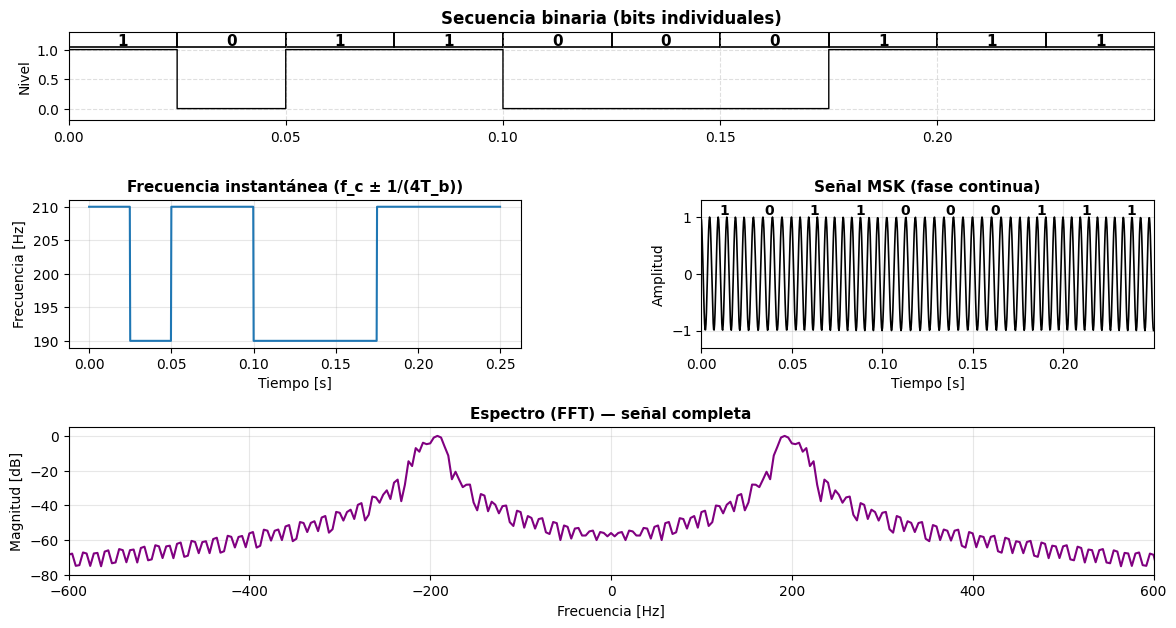

In [48]:
# ================================================================
# MSK - Evolución temporal y espectral (bits, frecuencia, oscilograma y FFT)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Parámetros
# -----------------------------
fs = 4000            # frecuencia de muestreo [Hz]
fc = 200             # frecuencia portadora [Hz]
Tb = 0.025           # duración de bit [s]
bits = np.array([1,0, 1,1, 0,0, 0,1, 1,1], dtype=int)

# -----------------------------
# Variables derivadas
# -----------------------------
N_bits = len(bits)
Ns_bit = int(np.round(fs * Tb))
t_total = np.linspace(0, N_bits*Tb, N_bits*Ns_bit, endpoint=False)

# niveles NRZ bipolar: 0 -> -1, 1 -> +1
def bit_to_level(b): return 2*b - 1
levels = bit_to_level(bits)

# señal baseband NRZ (rectangular)
data_nrz = np.repeat(levels, Ns_bit)

# -----------------------------
# Construcción de la fase continua (CPFSK con h=0.5)
# -----------------------------
# Índice de modulación h = 0.5 → Δf = 1/(4Tb)
Df = 1 / (4*Tb)
# frecuencia instantánea
f_inst = fc + Df * data_nrz
# fase acumulada
phi = 2*np.pi*np.cumsum(f_inst) / fs
# señal MSK pasabanda
s_msk = np.cos(phi)

# -----------------------------
# FFT con ventana Hann
# -----------------------------
def compute_fft(signal, fs):
    N = len(signal)
    window = np.hanning(N)
    S = np.fft.fftshift(np.fft.fft(signal * window, n=N))
    f = np.fft.fftshift(np.fft.fftfreq(N, d=1.0/fs))
    S_mag = np.abs(S)
    S_db = 20 * np.log10(S_mag / (S_mag.max() + 1e-12) + 1e-12)
    return f, S_db

f_tot, S_tot_db = compute_fft(s_msk, fs)

# -----------------------------
# GRÁFICOS ESTÁTICOS
# -----------------------------
fig = plt.figure(figsize=(14,10))
gs = fig.add_gridspec(4, 2, height_ratios=[0.6, 1.0, 1.0, 1.0], hspace=0.6, wspace=0.4)

# 1) bits
ax_bits = fig.add_subplot(gs[0, :])
ax_bits.step(t_total, np.repeat(bits, Ns_bit), where='post', color='k', lw=1)
ax_bits.set_ylim(-0.2, 1.3)
ax_bits.set_xlim(0, t_total[-1])
ax_bits.set_title("Secuencia binaria (bits individuales)", fontsize=12, fontweight='bold')
ax_bits.set_ylabel("Nivel")
ax_bits.grid(True, ls='--', alpha=0.4)
for i, b in enumerate(bits):
    x0 = i * Tb
    ax_bits.add_patch(Rectangle((x0, 1.05), Tb, 0.25, fill=False, edgecolor='k', linewidth=1.2))
    ax_bits.text(x0 + Tb/2, 1.15, str(b), ha='center', va='center', fontsize=11, fontweight='bold')

# 2) Frecuencia instantánea
ax_fi = fig.add_subplot(gs[1, 0])
ax_fi.plot(t_total, f_inst, color='tab:blue')
ax_fi.set_title("Frecuencia instantánea (f_c ± 1/(4T_b))", fontsize=11, fontweight='bold')
ax_fi.set_xlabel("Tiempo [s]")
ax_fi.set_ylabel("Frecuencia [Hz]")
ax_fi.grid(True, alpha=0.3)

# 3) Señal MSK
ax_sig = fig.add_subplot(gs[1, 1])
ax_sig.plot(t_total, s_msk, color='k', lw=1.2)
for i in range(N_bits):
    start = i * Tb
    ax_sig.text(start + Tb/2, 1.05, str(bits[i]), ha='center', fontsize=10, fontweight='bold')
ax_sig.set_title("Señal MSK (fase continua)", fontsize=11, fontweight='bold')
ax_sig.set_xlim(0, t_total[-1])
ax_sig.set_ylim(-1.3, 1.3)
ax_sig.set_xlabel("Tiempo [s]")
ax_sig.set_ylabel("Amplitud")
ax_sig.grid(True, alpha=0.3)

# 4) Espectro
ax_spec = fig.add_subplot(gs[2, :])
ax_spec.plot(f_tot, S_tot_db, color='purple', lw=1.5)
ax_spec.set_title("Espectro (FFT) — señal completa", fontsize=11, fontweight='bold')
ax_spec.set_xlim(-600, 600)
ax_spec.set_ylim(-80, 5)
ax_spec.set_xlabel("Frecuencia [Hz]")
ax_spec.set_ylabel("Magnitud [dB]")
ax_spec.grid(True, which='both', alpha=0.3)

plt.show()

# -----------------------------
# ANIMACIÓN MSK
# -----------------------------
fig2, (ax_t, ax_f) = plt.subplots(2,1, figsize=(12,6))
plt.subplots_adjust(hspace=0.4)
ax_t.set_xlim(0, t_total[-1])
ax_t.set_ylim(-1.3, 1.3)
ax_t.set_xlabel("Tiempo [s]")
ax_t.set_ylabel("Amplitud")
ax_t.set_title("Evolución temporal (acumulativa) - MSK")

ax_f.set_xlim(-600, 600)
ax_f.set_ylim(-80, 5)
ax_f.set_xlabel("Frecuencia [Hz]")
ax_f.set_ylabel("Magnitud [dB]")
ax_f.set_title("Evolución del espectro (acumulativo)")

line_t, = ax_t.plot([], [], color='k', lw=1.2)
fill_patch = None
line_f, = ax_f.plot([], [], color='purple', lw=1.5)

def update(frame):
    global fill_patch
    n_samples_partial = min((frame+1)*Ns_bit, len(t_total))
    s_part = s_msk.copy()
    s_part[n_samples_partial:] = 0
    line_t.set_data(t_total, s_part)
    if fill_patch:
        try: fill_patch.remove()
        except Exception: pass
    start_t = frame * Tb
    end_t = start_t + Tb
    mask = (t_total >= start_t) & (t_total < end_t)
    fill_patch = ax_t.fill_between(t_total[mask], s_part[mask], 0, color='tab:gray', alpha=0.25)
    f_p, S_p_db = compute_fft(s_part, fs)
    line_f.set_data(f_p, S_p_db)
    ax_t.set_title(f"Evolución temporal (bits transmitidos: {frame+1}/{N_bits})")
    return line_t, line_f, fill_patch

anim = FuncAnimation(fig2, update, frames=N_bits, interval=900, blit=False, repeat=True)

plt.close(fig2)
HTML(anim.to_jshtml())


#**MSK (Minimum Shift Keying)**

A continuación, se detalla el procedimiento que implementa la señal MSK, su espectro y el análisis de fase continua, esencialmente un CPFSK con índice $h=0.5$.

---

## 1. Parámetros Básicos y Discretización

Se definen las constantes de tiempo y la discretización con un paso $T_{\text{s}} = \dfrac{1}{f_s}$:

* **Tiempo Discreto Total:**
    $$
    t[n] = n T_{\text{s}},\qquad n=0,1,\dots,N_{\text{total}}-1.
    $$
* **Muestras por Bit:**
    $$
    N_s^{(b)} = \mathrm{round}(f_s T_b).
    $$

---

## 2. Mapeo de Bits a Niveles NRZ Bipolar

Cada bit $b_k \in \{0,1\}$ se convierte a un nivel de amplitud $a_k \in \{-1,+1\}$:
$$
a_k = 2 b_k - 1.
$$
La señal baseband rectangular (NRZ) muestreada $a[n]$ se construye repitiendo $a_k$ durante $N_s^{(b)}$ muestras.

---

## 3. MSK como CPFSK con Índice $h=0.5$

MSK es una modulación de Desplazamiento de Frecuencia con Fase Continua (CPFSK) con un índice de modulación $h = 0.5$.

**Relación Frecuencia/Índice:** El índice $h$ determina el desplazamiento de frecuencia mínima ($\Delta f$) para que las dos frecuencias sean ortogonales en el intervalo $T_b$:
$$
h = 2 \Delta f \, T_b.
$$
Dado $h=0.5$, el desplazamiento de frecuencia es:
$$
\Delta f = \frac{0.5}{2T_b} = \frac{1}{4T_b}.
$$
La **frecuencia instantánea** $f_{\text{inst}}$ cambia por bit:
$$
f_{\text{inst}}[n] = f_c + \Delta f \cdot a[n],
$$
donde $a[n] \in \{-1,+1\}$ modula la frecuencia de la portadora $f_c$.

---

## 4. Fase Acumulada y Continuidad ($\varphi(t)$)

La señal MSK en banda pasante es $s(t) = A\cos\big(2\pi f_c t + \varphi(t)\big)$. La fase $\varphi(t)$ es la integral de la desviación de frecuencia respecto a $f_c$, garantizando la **Continuidad de Fase**:
$$
\varphi(t) = 2\pi \int_0^t \big(f(\tau)-f_c\big)\,d\tau = 2\pi \Delta f \int_0^t a(\tau)\,d\tau.
$$
En la implementación discreta, la fase acumulada en la muestra $n$ se calcula mediante una suma acumulativa (integración numérica):
$$
\varphi[n] = 2\pi \frac{1}{f_s}\sum_{m=0}^{n} f_{\text{inst}}[m].
$$
Separando la contribución de $f_c$ y $\Delta f$:
$$
\varphi[n] = 2\pi f_c \frac{n}{f_s} + 2\pi \Delta f \frac{1}{f_s}\sum_{m=0}^{n} a[m].
$$
La señal MSK discreta final es:
$$
s[n] = \cos\big(\varphi[n]\big).
$$
*La **continuidad** de $\varphi[n]$ es clave: asegura que la energía espectral se concentre alrededor de $f_c$, reduciendo los lóbulos laterales.*

---

## 5. Cálculo Numérico de la FFT y Espectro

Sea $s[n]$ la señal discreta de longitud $N$.

1.  **Ventana de Hann ($w[n]$):** Aplicada para mitigar el *spectral leakage*.
    $$
    w[n] = 0.5\Big(1 - \cos\!\frac{2\pi n}{N-1}\Big).
    $$

2.  **Transformada Discreta de Fourier (DFT) Centrada:**
    $$
    S[k] = \sum_{n=0}^{N-1} \big(s[n]\cdot w[n]\big)\,e^{-j 2\pi \frac{k n}{N}}.
    $$
    El vector de frecuencias (ordenado) es $f[k] = \left(\frac{k}{N} - \frac{1}{2}\right) f_s$.

3.  **Normalización en dB:** Para expresar el espectro con el pico máximo en $0\ \mathrm{dB}$:
    $$
    S_{\mathrm{dB}}[k] = 20\log_{10}\!\Big(\frac{|S[k]|}{\max_k|S[k]| + \varepsilon} + \varepsilon\Big),
    $$
    donde $\varepsilon \approx 10^{-12}$.

4.  **Resolución Espectral:** Está dada por el tamaño de la FFT: $\Delta f = f_s/N$.

---

## 6. Interpretación de Resultados y Ventajas

* **Frecuencia Instantánea:** Alterna de forma abrupta entre $f_c + \Delta f$ (para $b=1$) y $f_c - \Delta f$ (para $b=0$).
* **Fase Acumulada:** Se mantiene continua. Al final de cada intervalo $T_b$, la fase ha cambiado exactamente $\pm \pi/2$ (pues $\Delta f \cdot T_b = 1/4$, y $2\pi \Delta f T_b = \pi/2$).
* **Espectro:** La continuidad de fase resulta en una atenuación de los lóbulos laterales mucho más rápida que las modulaciones FSK o QPSK con pulsos rectangulares, lo que hace a MSK muy atractivo para aplicaciones donde la **eficiencia espectral** (minimizar la interferencia a canales vecinos) es prioritaria.

---

## 7. Fórmulas Clave (Para Implementación)

| Concepto | Fórmula |
| :--- | :--- |
| **Desplazamiento $\Delta f$** | $\Delta f = \dfrac{1}{4T_b}$ |
| **Frecuencia Inst.** | $f_{\text{inst}}[n] = f_c + \Delta f \cdot a[n]$ |
| **Fase Acumulada** | $\varphi[n] = 2\pi \frac{1}{f_s}\sum_{m=0}^{n} f_{\text{inst}}[m]$ |
| **Señal MSK** | $s[n] = \cos\big(\varphi[n]\big)$ |

#**SFSK**

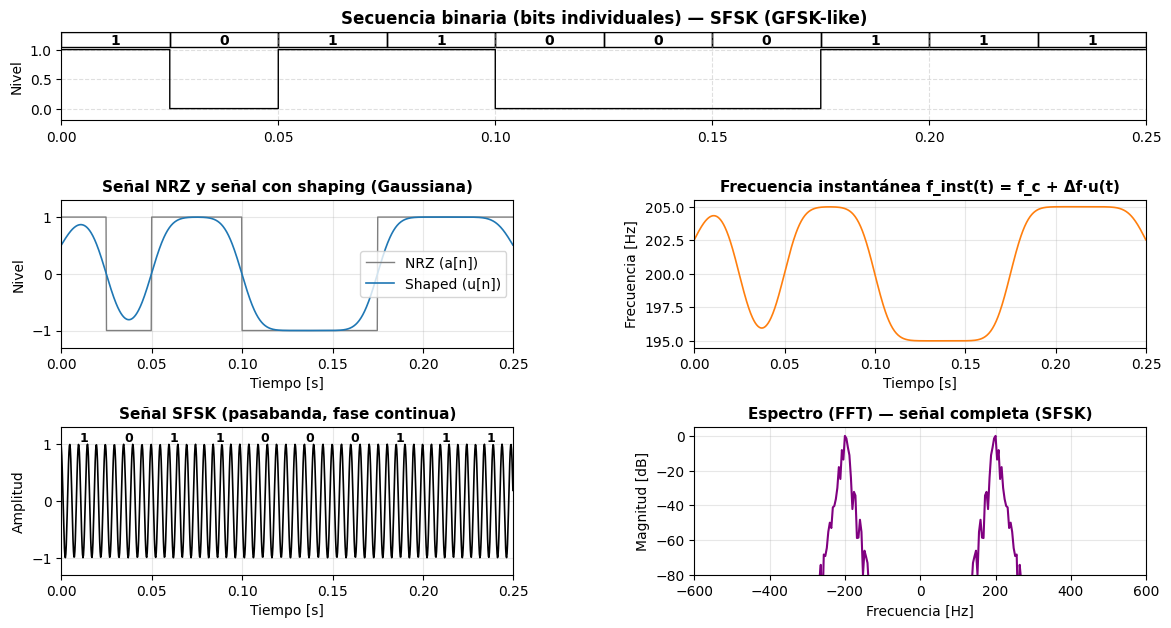

In [49]:
# ================================================================
# SFSK (GFSK-like) - Evolución temporal y espectral (bits, shaping, f_inst, oscilograma y FFT)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Parámetros configurables
# -----------------------------
fs = 4000            # frecuencia de muestreo [Hz]
fc = 200             # frecuencia portadora [Hz]
Tb = 0.025           # duración de bit [s]
bits = np.array([1,0, 1,1, 0,0, 0,1, 1,1], dtype=int)   # secuencia de bits

# Parámetros de shaping (Gaussiano)
BT = 0.3             # producto Bandwidth-Time para filtro gaussiano (valores típicos: 0.3, 0.5, 1.0)
span_symbols = 4     # span del filtro en símbolos (largo total = span_symbols * Tb a cada lado)
# Desviación de frecuencia nominal (ajustable)
Delta_f = 1.0 / (8.0 * Tb)   # separación de tonos; para MSK usar 1/(4Tb). Aquí usamos un valor intermedio.

# -----------------------------
# Parámetros derivados
# -----------------------------
N_bits = len(bits)
Ns_bit = int(np.round(fs * Tb))                     # muestras por bit
N_total = N_bits * Ns_bit
t_total = np.linspace(0, N_bits*Tb, N_total, endpoint=False)

# -----------------------------
# 1) Mapeo NRZ bipolar y expansión a muestras
# -----------------------------
def bit_to_level(b): return 2*b - 1
levels = bit_to_level(bits)                          # +1 / -1
a_samples = np.repeat(levels, Ns_bit)               # señal NRZ muestreada

# -----------------------------
# 2) Diseño filtro Gaussiano (discreto) - aproximación práctica
#    Relación simplificada: sigma ~ (BT * Tb)
#    Nota: relación exacta para GMSK es más precisa; aquí usamos una aproximación práctica.
# -----------------------------
# tiempo del kernel (simétrico)
kernel_half_len = int(span_symbols * Ns_bit)        # mediosamples a cada lado
t_kernel = np.linspace(-span_symbols*Tb, span_symbols*Tb, 2*kernel_half_len + 1)
sigma = BT * Tb                                     # desviación típica (approx)
h = np.exp(-0.5 * (t_kernel / sigma)**2)
h = h / np.sum(h)                                   # normalizar área a 1 (filtro pasa-banda normalizado)

# -----------------------------
# 3) Filtrado (shaping) de la señal NRZ -> u[n] en [-1, +1] aproximadamente
# -----------------------------
u_full = np.convolve(a_samples, h, mode='same')    # señal suavizada (shaped)
# normalizar para asegurar rango [-1,1]
max_abs = np.max(np.abs(u_full))
if max_abs == 0:
    u = u_full
else:
    u = u_full / max_abs

# -----------------------------
# 4) Frecuencia instantánea y fase acumulada
# -----------------------------
f_inst = fc + Delta_f * u                           # f_inst en Hz (varía suavemente)
phi = 2.0 * np.pi * np.cumsum(f_inst) / fs         # fase acumulada (radianes)
s_sfsK = np.cos(phi)                                # señal transmitida (pasabanda)

# -----------------------------
# Función FFT (ventana Hann)
# -----------------------------
def compute_fft(signal, fs):
    N = len(signal)
    window = np.hanning(N)
    S = np.fft.fftshift(np.fft.fft(signal * window, n=N))
    f = np.fft.fftshift(np.fft.fftfreq(N, d=1.0/fs))
    S_mag = np.abs(S)
    S_db = 20 * np.log10(S_mag / (S_mag.max() + 1e-12) + 1e-12)
    return f, S_db

f_tot, S_tot_db = compute_fft(s_sfsK, fs)

# -----------------------------
# GRÁFICOS ESTÁTICOS (estructura similar a tus códigos previos)
# -----------------------------
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(4, 2, height_ratios=[0.6, 1.0, 1.0, 1.0], hspace=0.6, wspace=0.4)

# 1) bit stream (top full width)
ax_bits = fig.add_subplot(gs[0, :])
ax_bits.step(np.repeat(t_total, 1), np.repeat(bits, Ns_bit), where='post', color='k', lw=1)
ax_bits.set_ylim(-0.2, 1.3)
ax_bits.set_xlim(0, t_total[-1] + (1/fs))
ax_bits.set_title("Secuencia binaria (bits individuales) — SFSK (GFSK-like)", fontsize=12, fontweight='bold')
ax_bits.set_ylabel("Nivel")
ax_bits.grid(True, ls='--', alpha=0.4)
for i, b in enumerate(bits):
    x0 = i * Tb
    ax_bits.add_patch(Rectangle((x0, 1.05), Tb, 0.25, fill=False, edgecolor='k', linewidth=1.0))
    ax_bits.text(x0 + Tb/2, 1.15, str(b), ha='center', va='center', fontsize=10, fontweight='bold')

# 2) Señal NRZ y señal moldeada u[n] (left middle)
ax_u = fig.add_subplot(gs[1, 0])
ax_u.plot(t_total, a_samples, label='NRZ (a[n])', color='tab:gray', lw=1)
ax_u.plot(t_total, u, label='Shaped (u[n])', color='tab:blue', lw=1.2)
ax_u.set_title("Señal NRZ y señal con shaping (Gaussiana)", fontsize=11, fontweight='bold')
ax_u.set_xlim(0, t_total[-1] + (1/fs))
ax_u.set_ylim(-1.3, 1.3)
ax_u.set_xlabel("Tiempo [s]")
ax_u.set_ylabel("Nivel")
ax_u.grid(True, alpha=0.3)
ax_u.legend()

# 3) Frecuencia instantánea y portadora (right middle)
ax_fi = fig.add_subplot(gs[1, 1])
ax_fi.plot(t_total, f_inst, color='tab:orange', lw=1.2)
ax_fi.set_title("Frecuencia instantánea f_inst(t) = f_c + Δf·u(t)", fontsize=11, fontweight='bold')
ax_fi.set_xlim(0, t_total[-1] + (1/fs))
ax_fi.set_xlabel("Tiempo [s]")
ax_fi.set_ylabel("Frecuencia [Hz]")
ax_fi.grid(True, alpha=0.3)

# 4) Oscilograma (lower left)
ax_sig = fig.add_subplot(gs[2, 0])
ax_sig.plot(t_total, s_sfsK, color='k', lw=1.2)
# resaltar cada bit
for i in range(N_bits):
    start = i * Tb
    ax_sig.text(start + Tb/2, 1.05, str(bits[i]), ha='center', fontsize=9, fontweight='bold')
ax_sig.set_title("Señal SFSK (pasabanda, fase continua)", fontsize=11, fontweight='bold')
ax_sig.set_xlim(0, t_total[-1] + (1/fs))
ax_sig.set_ylim(-1.3, 1.3)
ax_sig.set_xlabel("Tiempo [s]")
ax_sig.set_ylabel("Amplitud")
ax_sig.grid(True, alpha=0.3)

# 5) Espectro (lower right)
ax_spec = fig.add_subplot(gs[2, 1])
ax_spec.plot(f_tot, S_tot_db, color='purple', lw=1.5)
ax_spec.set_title("Espectro (FFT) — señal completa (SFSK)", fontsize=11, fontweight='bold')
ax_spec.set_xlim(-600, 600)
ax_spec.set_ylim(-80, 5)
ax_spec.set_xlabel("Frecuencia [Hz]")
ax_spec.set_ylabel("Magnitud [dB]")
ax_spec.grid(True, which='both', alpha=0.3)

plt.show()

# -----------------------------
# ANIMACIÓN: evolución por bit (mostrar oscilograma parcial y FFT parcial)
# -----------------------------
fig2, (ax_t, ax_f) = plt.subplots(2,1, figsize=(12,6))
plt.subplots_adjust(hspace=0.4)
ax_t.set_xlim(0, t_total[-1] + (1/fs))
ax_t.set_ylim(-1.3, 1.3)
ax_t.set_xlabel("Tiempo [s]")
ax_t.set_ylabel("Amplitud")
ax_t.set_title("Evolución temporal (acumulativa) - SFSK")

ax_f.set_xlim(-600, 600)
ax_f.set_ylim(-80, 5)
ax_f.set_xlabel("Frecuencia [Hz]")
ax_f.set_ylabel("Magnitud [dB]")
ax_f.set_title("Evolución del espectro (acumulativo) - SFSK")

line_t, = ax_t.plot([], [], color='k', lw=1.2)
fill_patch = None
line_f, = ax_f.plot([], [], color='purple', lw=1.5)

def update(frame):
    global fill_patch
    # frame goes de 0 a N_bits-1 (actualizamos por bit)
    n_samples_partial = min((frame+1) * Ns_bit, len(t_total))
    # señal parcial acumulada (ceros después de n_samples_partial)
    s_part = s_sfsK.copy()
    s_part[n_samples_partial:] = 0.0

    # actualizar tiempo
    line_t.set_data(t_total, s_part)
    if fill_patch:
        try:
            fill_patch.remove()
        except Exception:
            pass
    # resaltar región del bit actual
    start_t = frame * Tb
    mask = (t_total >= start_t) & (t_total < (start_t + Tb))
    fill_patch = ax_t.fill_between(t_total[mask], s_part[mask], 0, color='tab:gray', alpha=0.25)

    # FFT parcial y actualización
    f_p, S_p_db = compute_fft(s_part, fs)
    line_f.set_data(f_p, S_p_db)

    ax_t.set_title(f"Evolución temporal (bits transmitidos: {frame+1}/{N_bits})")
    return line_t, line_f, fill_patch

anim = FuncAnimation(fig2, update, frames=N_bits, interval=900, blit=False, repeat=True)

# mostrar animación inline en Jupyter/Colab
plt.close(fig2)
HTML(anim.to_jshtml())


#**Explicación Matemática y Procedimiento SFSK (Shaped FSK / GFSK)**


---

## 1. Parámetros Básicos y Discretización Temporal

Se establecen las constantes de la simulación:

| Parámetro | Símbolo | Definición |
| :--- | :--- | :--- |
| Paso de Muestreo | $T_s$ | $T_s=\dfrac{1}{f_s}$ |
| Muestras por Bit | $N_s^{(b)}$ | $N_s^{(b)}=\mathrm{round}(f_s\,T_b)$ |
| Longitud Total | $N_{\text{total}}$ | $N_{\text{total}} = N_{\text{bits}}\;N_s^{(b)}$ |

El vector de tiempo discreto es:
$$
t[n]=nT_s,\qquad n=0,\dots,N_{\text{total}}-1.
$$

---

## 2. Mapeo de Bits a Niveles NRZ Bipolar

Los bits $b_k\in\{0,1\}$ se mapean a niveles bipolares $a_k\in\{-1,+1\}$:
$$
a_k = 2 b_k - 1.
$$
La señal NRZ muestreada $a[n]$ se obtiene repitiendo $a_k$ por $N_s^{(b)}$ muestras.

---

## 3. Diseño del Filtro de Shaping (Kernel Gaussiano)

La clave del SFSK es el filtro de conformación de pulso, típicamente Gaussiano.

1.  **Respuesta Temporal Continua (Gaussiana):**
    $$
    h(\tau)=\exp\!\Big(-\tfrac{1}{2}\Big(\frac{\tau}{\sigma}\Big)^2\Big)
    $$
    donde $\sigma$ es la desviación temporal, relacionada con el parámetro *Bandwidth-Time* ($BT$).

2.  **Aproximación Numérica de $\sigma$:** El código utiliza la relación práctica:
    $$
    \sigma \approx BT\cdot T_b.
    $$
    *(Esta es una aproximación conveniente; la relación exacta dependería de la definición de ancho de banda, p. ej., a $-3\ \mathrm{dB}$).*

3.  **Normalización del Kernel Discreto:** El kernel discreto $h[n]$ se normaliza para mantener la ganancia unitaria:
    $$
    h[n] \leftarrow \frac{h[n]}{\sum_m h[m]}.
    $$

---

## 4. Filtrado (Convolución) — Señal Shaped Baseband

La señal base filtrada (suavizada) $u[n]$ se obtiene por **convolución discreta** entre la señal NRZ $a[n]$ y el kernel Gaussiano $h[n]$:
$$
u[n] = (a * h)[n] = \sum_{m} a[m]\; h[n-m].
$$
El filtro suaviza las transiciones abruptas del NRZ. Para asegurar que $u[n]$ mantenga el rango $\pm 1$:
$$
u[n] \leftarrow \frac{u[n]}{\max_n |u[n]|}.
$$
Después de esta normalización, $u[n]\in[-1,1]$.

---

## 5. Conversión a Frecuencia Instantánea (FSK Suavizado)

La señal $u[n]$ modula la frecuencia de la portadora $f_c$.

**Frecuencia Instantánea Discreta:**
$$
f_{\text{inst}}[n] = f_c + \Delta f\; u[n],
$$
donde $\Delta f$ es la desviación de frecuencia máxima (p. ej., $\Delta f = 1/(8T_b)$ en el código de ejemplo). $\Delta f$ controla la separación de los tonos y el índice de modulación $h = 2\Delta f T_b$.

---

## 6. Fase Acumulada y Continuidad de Fase

La fase acumulada discreta $\varphi[n]$ se obtiene por integración numérica de la frecuencia instantánea (suma acumulada):
$$
\varphi[n] = 2\pi \sum_{m=0}^{n} \frac{f_{\text{inst}}[m]}{f_s} = 2\pi \frac{1}{f_s}\sum_{m=0}^{n} f_{\text{inst}}[m].
$$
La continuidad de fase $\Delta\varphi[n] = 2\pi f_{\text{inst}}[n]/f_s$ es la propiedad clave: las transiciones suaves de $u[n]$ garantizan que no haya saltos bruscos en $\varphi[n]$, lo que reduce los lóbulos laterales.

---

## 7. Señal Transmitida (Pasabanda) y Análisis Espectral

**Señal SFSK Pasabanda:**
$$
s[n] = \cos\big(\varphi[n]\big).
$$

**Análisis Espectral (FFT con Ventana Hann y Normalización a dB):**
1. **Ventana** (Hann) $w[n]$ aplicada a $s[n]$.
2. **DFT** $S[k]$ calculada sobre la señal ventaneada (usando $\operatorname{fftshift}$):
$$
S[k] = \sum_{n=0}^{N-1} s[n]\,w[n]\,e^{-j2\pi k n / N}.
$$
3. **Magnitud en dB** (Normalizada):
$$
S_{\text{dB}}[k] = 20\log_{10}\!\Big(\frac{|S[k]|}{\max_{\ell}|S[\ell]| + \varepsilon} + \varepsilon\Big).
$$

---

## 8. Resumen Compacto de Fórmulas

| Componente | Ecuación Clave |
| :--- | :--- |
| **Shaping** | $u[n] = (a * h)[n]$ (con $h[n]$ Gaussiano normalizado) |
| **Frec. Inst.** | $f_{\text{inst}}[n] = f_c + \Delta f\; u[n]$ |
| **Fase Acumulada** | $\varphi[n] = 2\pi \frac{1}{f_s}\sum_{m=0}^{n} f_{\text{inst}}[m]$ |
| **Señal SFSK** | $s[n] = \cos\big(\varphi[n]\big)$ |

---

## 9. Efectos  Observables

* **Espectro Compaccto:** El *shaping* Gaussiano suaviza las transiciones de $a[n]$, lo que resulta en una señal $u[n]$ sin discontinuidades. Esto minimiza el contenido de alta frecuencia, concentrando la energía del espectro alrededor de $f_c$ y reduciendo los lóbulos laterales de forma muy efectiva.
* **Trade-off $BT$:** Un valor bajo de $BT$ implica un filtro más estrecho en frecuencia (mejor rechazo de lóbulos) pero más ancho en el tiempo, aumentando la **Interferencia Intersimbólica (ISI)**.

---

*¡El MSK/GFSK es un pilar en la eficiencia espectral!* La clave de todo es entender que el **filtrado en banda base ($u[n]$)** se traduce directamente en la **continuidad y suavidad de la fase $\varphi[n]$** en banda pasante.


#**Comparación de Modulaciones Digitales (QPSK, OQPSK, MSK, ASK, SFSK)**

Este análisis compara rigurosamente cinco técnicas de modulación digital, destacando sus bases matemáticas y sus implicaciones espectrales y prácticas.

---

## 1. Modulaciones en Cuadratura (QPSK, OQPSK, MSK)

| **Modulación** | **QPSK** (Phase) | **OQPSK** (Offset Phase) | **MSK** (Continuous Phase Freq.) |
| :--- | :--- | :--- | :--- |
| **Concepto** | Modulación de fase con saltos de $\pm 90^\circ$ o $180^\circ$. | QPSK con canal $Q$ retrasado $T_b$ para evitar saltos de $180^\circ$. | CPFSK con índice $h=0.5$. Puede verse como OQPSK con pulso senoidal. |
| **Ecuación Esencial** | $s(t) = \sqrt{\frac{2E_s}{T_s}} \cos\left(2\pi f_c t + \phi_k\right)$ | $s(t) = I(t)\cos(2\pi f_c t) - Q(t-T_b)\sin(2\pi f_c t)$ | $s(t) = \sqrt{\frac{2E_b}{T_b}} \cos\left[ 2\pi f_c t + \phi(t) \right]$ |
| **Fase Continua** | **No**. Saltos bruscos, riesgo de envolvente cero. | **Parcial**. Limita saltos a $\pm 90^\circ$. Envolvente más constante. | **Sí**. Fase y frecuencia continuas $\phi(t) = 2\pi \int f_i(\tau)d\tau$. |
| **Ancho de Banda** | Medio. Lóbulos laterales moderados. | Medio. Similar a QPSK en BW, pero mejor **linealidad**. | **Estrecho**. Lóbulos laterales muy atenuados. |
| **Eficiencia ($\eta$)** | $\eta = 2 \text{ bits/símbolo}$. Alta. | $\eta = 2 \text{ bits/símbolo}$. Alta. | $\eta = 1 \text{ bit}/T_b$ (efectiva). Muy buena compacidad. |
| **Desv. Frecuencia** | N/A | N/A | Mínima: $\Delta f = \dfrac{1}{4T_b}$. |

---

## 2. Modulaciones ASK y SFSK (FSK Filtrada)

| **Modulación** | **ASK** (Amplitude Shift Keying) | **SFSK/GFSK** (Shaped FSK) |
| :--- | :--- | :--- |
| **Concepto** | Modulación de amplitud. Simplicidad extrema. | FSK donde la señal de banda base $a(t)$ se filtra con un pulso Gaussiano $h(t)$. |
| **Ecuación Esencial** | $s(t) = A_k \cos(2\pi f_c t)$ | $s(t) = \cos\left[ 2\pi \int_0^t \left(f_c + \Delta f \cdot m(\tau)\right)d\tau \right]$ |
| **Fase Continua** | **No**. Discontinuidad de amplitud y fase. | **Sí**. La función $m(t)=(a*h)(t)$ es suave y continua. |
| **Ancho de Banda** | **Amplio**. Fuerte dependencia de las transiciones $A_k$. | **Muy Estrecho**. Controlable por el parámetro $BT$ ($\sigma \approx BT \cdot T_b$). |
| **Robustez/Ruido** | **Baja**. Muy sensible a fluctuaciones de canal. | **Baja/Media**. FSK inherente, pero el *shaping* aumenta la robustez espectral. |
| **Aplicaciones** | OOK, RFID, infrarrojos. | Bluetooth, Zigbee, sistemas de baja potencia. |

---

## 3. Conclusión

| Criterio Clave | Mejor Opción | Razón Fundamental |
| :--- | :--- | :--- |
| **Eficiencia Espectral** ($\eta$) | **QPSK / OQPSK** | Transmiten 2 bits por símbolo $(2\text{ bits}/T_s)$, el máximo entre estas. |
| **Linealidad / Robustez de Envolvente** | **MSK / OQPSK** | Evitan o minimizan los saltos de $180^\circ$ que causan que la envolvente pase por cero. |
| **Compacidad Espectral (BW)** | **SFSK (GFSK) / MSK** | La fase continua, junto con el *shaping* Gaussiano, garantiza la mayor atenuación de lóbulos laterales. |
| **Simplicidad de Diseño** | **ASK** | Implementación más sencilla de todas. |

**El enfoque de MSK/SFSK (CPFSK)**, al integrar la continuidad de fase y el *shaping* de pulso, ofrece el **mejor compromiso** para sistemas modernos donde la **eficiencia de amplificación** (mantener la envolvente constante) y el **control estricto de la interferencia a canales adyacentes** son requisitos de diseño no negociables.